# $\nu_{\tau}$ Investigation in the Dune Collaboration for Advanced Particle Physics Laboratory 2026 - NN Training
Author: Grzegorz Jędrzejowski \
Supervision: prof. Katarzyna Grzelak


## Global Variables

In [50]:
demo = 0    #use val dataset to split it into small train, val, test and check the pipeline's health
track = 0   #deploy commet tracking
save = 0    #save checkpoints when training

# Includes

In [2]:
import os, sys, importlib
my_home = '/scratch1/gjedrzej/Lab'
os.chdir(my_home) #GJ path
sys.path.append(os.path.join(os.getcwd(), "python"))

In [3]:
requirements_path = os.path.join(my_home, 'requirements.txt')

%pip install --upgrade pip #Pip 21.3+ is required
%pip install -r {requirements_path}

#you might need to restart the kernel after installing requirements

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import comet_ml
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

2026-05-06 10:54:35.957269: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-06 10:54:36.638571: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-06 10:54:38.524853: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 10:54:42.049782: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Seeds

In [5]:
np.random.seed(42)
tf.random.set_seed(42)
#there is also one in pd in ml.get_train_val_subsets in shuffle

## Custom libraries

In [6]:
import analysis.scripts.convert_full_nodebug as kg
importlib.reload(kg)

import analysis.scripts.convert_skwarek as sk
importlib.reload(sk)

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

import analysis.scripts.ml_functions as ml
importlib.reload(ml)

import analysis.scripts.system_functions as sf
importlib.reload(sf)

import analysis.scripts.preprocess_functions as prf
importlib.reload(prf)


output_dir = 'analysis/processedData'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")

/scratch1/gjedrzej/.local/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/scratch1/gjedrzej/.local/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


## CSV Example Processing

In [7]:
if demo:
    FilePath_val = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
    output_path_val = os.path.join(output_dir, 'data_all_tau_val.csv')
    kg.extract_data(FilePath_val, output_path_val)

# File Paths

In [8]:
if not demo:
    output_path_val = os.path.join(output_dir, 'data_all_tau_val.csv')
    output_path_test = os.path.join(output_dir, 'data_all_tau_test.csv')
    output_path_train_cc = os.path.join(output_dir, 'data_CC_train_cleaned.csv')
    output_path_train_nc = os.path.join(output_dir, 'data_NC_train_cleaned_ALL.csv')

## Preprocess Train, Val, Test
Features (12): <br>
               Charged Pions - Multiplicity, Leading (max momentum) Momentum, Leading Tranverse Momentum, Leading Cosine Theta <br>
               Neutral Pions - Multiplicity, Leading (max momentum) Momentum, Leading Tranverse Momentum, Leading Cosine Theta <br>
               Charged Particles - Multiplicity, Leading (max momentum) Momentum, Leading Tranverse Momentum, Leading Cosine Theta <br>
Labels (1): CCNC
Metadata (1): Interaction Type (QES, DIS, MEC, RES)

In [9]:
if demo:

    df_all = pd.read_csv(output_path_val)
    df_legacy=df_all.copy()

    #calculate features 
    df_pre = prf.get_feature_data(df_all.copy(), ['ch_pions', 'n_pions', 'charged'], feature=['multiplicity', 'p_leading', 'pt_leading', 'theta_leading', 'cos_theta_leading'])
    #remove old features
    df_pre = prf.clean_particle_data(df_pre)
    #change CC to 1 and NC to 0
    df_pre = prf.transform_ccnc(df_pre)
    #replace nans with 0 - Cos(theta) - nan -> 0!!! Possible problem, but it also has multiplicity, so it should learn when its also absent in the dataset
    df_pre = prf.fill_nans(df_pre)
    print(df_pre['CCNC'].value_counts())
    df_pre = prf.filter_int_types(df_pre, ['COH', 'NuEEL'])
    print(df_pre['CCNC'].value_counts())

    df_balanced_train, df_unbalanced_val, df_unbalanced_test = prf.get_physics_informed_split(df_pre, total_train_size=2000, total_val_size=400, total_test_size=400)


In [10]:
#Train - the csv is already preprocessed to some degree for computing efficiency (get_feature_data, clean_particle_data)
import analysis.scripts.preprocess_functions as prf
importlib.reload(prf)

if not demo:
#signal preprocess
    df_train_subset_cc = pd.read_csv(output_path_train_cc)
    df_train_subset_cc = prf.transform_ccnc(df_train_subset_cc) #'CC' -> 1, 'NC' -> 0 

    #background preprocess
    df_train_subset_nc = pd.read_csv(output_path_train_nc)
    df_train_subset_nc = prf.transform_ccnc(df_train_subset_nc) #'CC' -> 1, 'NC' -> 0 

    df_raw_training_data = prf.prepare_combined_pool(df_train_subset_cc, df_train_subset_nc) #for coherence checks

    df_raw_training_data = prf.fill_nans(df_raw_training_data) #handling nans

    df_legacy = df_raw_training_data #pointer for it to work with the same set up as demo

    #preprocess train
    df_balanced_train = df_raw_training_data.copy()
    df_balanced_train = prf.filter_int_types(df_balanced_train, ['COH', 'NuEEL']) #very rare classes

    #use 80% of the dataset for initial training - 200k per subclass, 8 subclasses (for each CC and NC 4 intTypes)
    df_balanced_train, _, _ = prf.get_physics_informed_split(df_balanced_train, total_train_size=1600000, total_val_size=0, total_test_size=0) 
    
    #use full dataset for regularization
    # df_balanced_train, _, _ = prf.get_physics_informed_split(df_balanced_train, total_train_size=2000000, total_val_size=0, total_test_size=0)

Pool Prepared:
  - Total Events: 16898467
  - CC Count: 5000000
  - NC Count: 11898467
Removed 68293 rows with IntTypes: ['COH', 'NuEEL']
Split Complete. Overlap Checks:


In [11]:
df_balanced_train.head()

,CCNC,EvtNum,IntType,multiplicity_ch_pions,p_leading_ch_pions,pt_leading_ch_pions,cos_theta_leading_ch_pions,multiplicity_charged,p_leading_charged,pt_leading_charged,cos_theta_leading_charged,multiplicity_n_pions,p_leading_n_pions,pt_leading_n_pions,cos_theta_leading_n_pions
0,1,1869904,RES,0,0.000000,0.000000,0.000000,6,9.957711,1.697672,0.985360,1,1.210111,0.922406,0.647283
1,1,4092912,DIS,0,0.000000,0.000000,0.000000,2,12.499304,1.040207,0.996531,1,1.019325,0.423079,0.909795
2,0,505809,RES,1,0.361777,0.360426,-0.086340,10,1.281408,0.423994,0.943672,0,0.000000,0.000000,0.000000
3,0,288221,DIS,1,0.397630,0.369913,-0.366815,2,3.369912,0.853837,0.967369,0,0.000000,0.000000,0.000000
4,0,758118,RES,0,0.000000,0.000000,0.000000,1,0.626031,0.493508,0.615275,0,0.000000,0.000000,0.000000


In [12]:
#Validation - this dataset is not preprocessed
if not demo:
    df_unbalanced_val = pd.read_csv(output_path_val)
    #calculate features 
    df_unbalanced_val = prf.get_feature_data(df_unbalanced_val, ['ch_pions', 'n_pions', 'charged'], feature=['multiplicity', 'p_leading', 'pt_leading', 'theta_leading', 'cos_theta_leading'])
    #remove old features
    df_unbalanced_val = prf.clean_particle_data(df_unbalanced_val)
    #change CC to 1 and NC to 0
    df_unbalanced_val = prf.transform_ccnc(df_unbalanced_val)
    #replace nans with 0 - Cos(theta) - nan -> 0!!! Possible problem, but it also has multiplicity, so it should learn when its also absent in the dataset
    df_unbalanced_val = prf.fill_nans(df_unbalanced_val)
    df_unbalanced_val = prf.filter_int_types(df_unbalanced_val, ['COH', 'NuEEL'])

    _, df_unbalanced_val, _ = prf.get_physics_informed_split(df_unbalanced_val, total_train_size=0, total_val_size=500000, total_test_size=0)



Removed 2652 rows with IntTypes: ['COH', 'NuEEL']
Split Complete. Overlap Checks:
  - Train/Val shared events:  0

[Validation Set Physics Profile]
CC/NC Ratio: {0: 0.896280039637427, 1: 0.10371996036257303}
Interaction Type Ratios:
IntType
DIS    0.415441
RES    0.361078
QES    0.194945
MEC    0.028537
Name: proportion, dtype: float64


In [13]:
#Test - this dataset is not preprocessed
if not demo:
    df_unbalanced_test = pd.read_csv(output_path_val)
    #calculate features 
    df_unbalanced_test = prf.get_feature_data(df_unbalanced_test, ['ch_pions', 'n_pions', 'charged'], feature=['multiplicity', 'p_leading', 'pt_leading', 'theta_leading', 'cos_theta_leading'])
    #remove old features
    df_unbalanced_test = prf.clean_particle_data(df_unbalanced_test)
    #change CC to 1 and NC to 0
    df_unbalanced_test = prf.transform_ccnc(df_unbalanced_test)
    #replace nans with 0 - Cos(theta) - nan -> 0!!! Possible problem, but it also has multiplicity, so it should learn when its also absent in the dataset
    df_unbalanced_test = prf.fill_nans(df_unbalanced_test)
    df_unbalanced_test = prf.filter_int_types(df_unbalanced_test, ['COH', 'NuEEL'])


    _, _, df_unbalanced_test = prf.get_physics_informed_split(df_unbalanced_test, total_train_size=0, total_val_size=0, total_test_size=500000)

Removed 2652 rows with IntTypes: ['COH', 'NuEEL']
Split Complete. Overlap Checks:
  - Train/Test shared events: 0

[Testing Set Physics Profile]
CC/NC Ratio: {0: 0.896280039637427, 1: 0.10371996036257303}
Interaction Type Ratios:
IntType
DIS    0.415441
RES    0.361078
QES    0.194945
MEC    0.028537
Name: proportion, dtype: float64


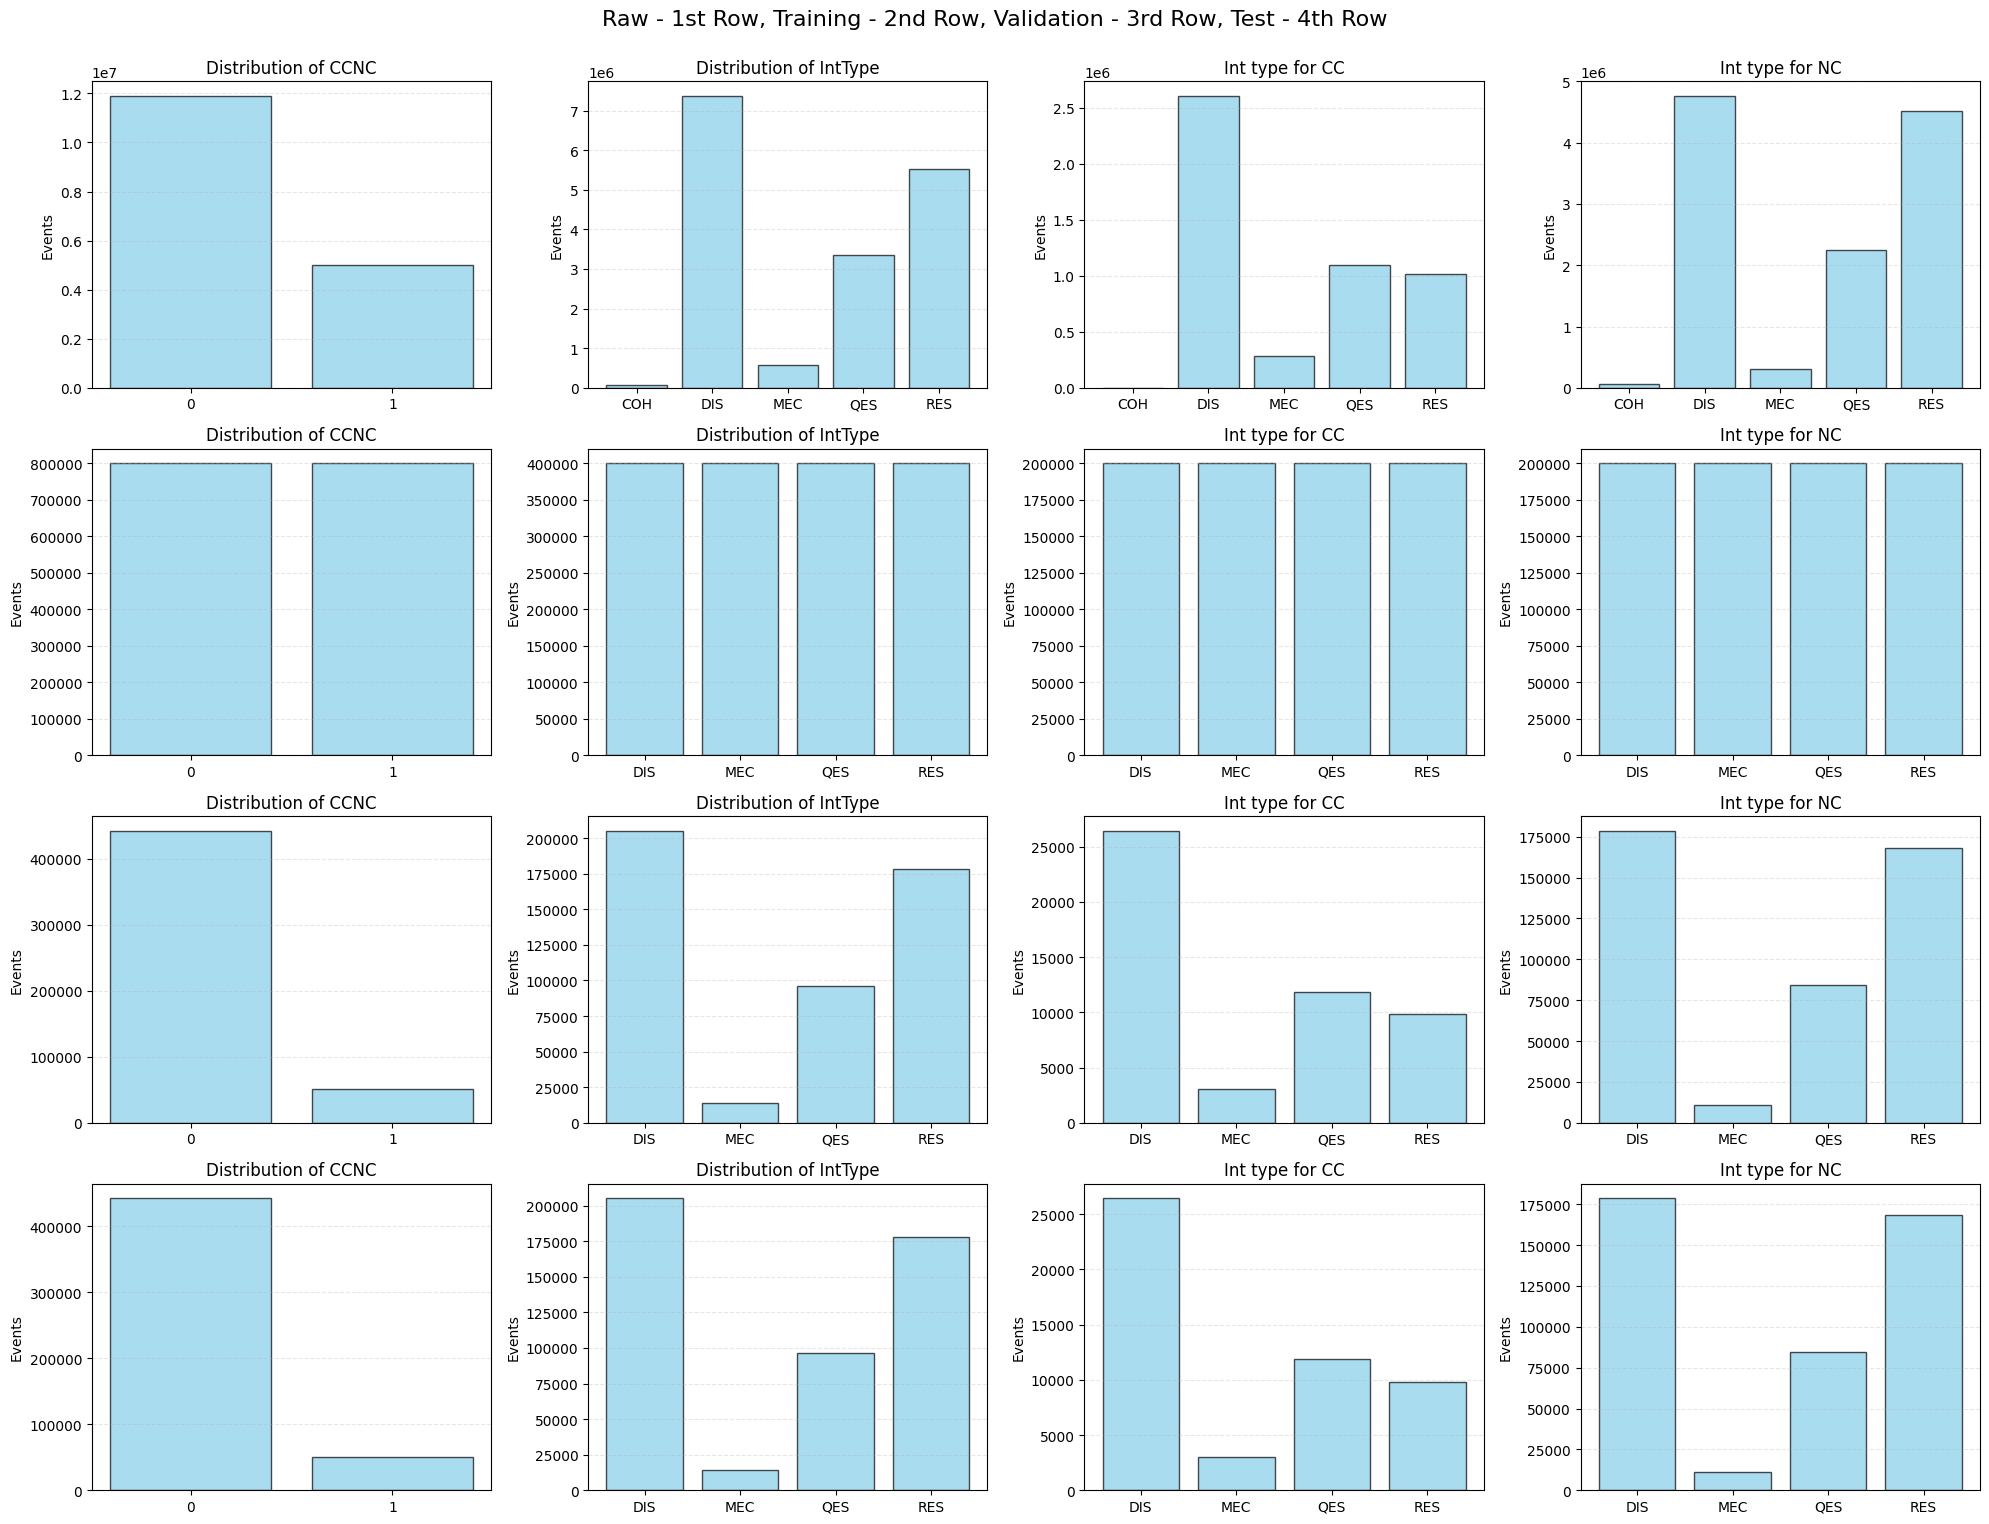

In [14]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

plt.suptitle("Raw - 1st Row, Training - 2nd Row, Validation - 3rd Row, Test - 4th Row", fontsize=16)

pf.plot_physics_results(df_legacy, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=False)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[0,1], density=False)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[0,2], density=False)
axes[0,2].set_title("Int type for CC")
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[0,3], density=False)
axes[0,3].set_title("Int type for NC")

pf.plot_physics_results(df_balanced_train, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[1,0], density=False)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[1,1], density=False)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[1,2], density=False)
axes[1,2].set_title("Int type for CC")
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[1,3], density=False)
axes[1,3].set_title("Int type for NC")

pf.plot_physics_results(df_unbalanced_val, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=False)
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[2,1], density=False)
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[2,2], density=False)
axes[2,2].set_title("Int type for CC")
pf.plot_physics_results(df_unbalanced_val, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[2,3], density=False)
axes[2,3].set_title("Int type for NC")

pf.plot_physics_results(df_unbalanced_test, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[3,0], density=False)
pf.plot_physics_results(df_unbalanced_test, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[3,1], density=False)
pf.plot_physics_results(df_unbalanced_test, column='IntType', ccnc_filter=1, int_filter=None, ax=axes[3,2], density=False)
axes[3,2].set_title("Int type for CC")
pf.plot_physics_results(df_unbalanced_test, column='IntType', ccnc_filter=0, int_filter=None, ax=axes[3,3], density=False)
axes[3,3].set_title("Int type for NC")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


# Plotting Class Separation Hypothesis for the Training Set
Histrogramy dla próbek wygenerowanych osobno dla CC (3.5-30 GeV, 5 mln) oraz NC (0.5-30 GeV, 12 mln).
Redukcja przypadków do 2 mln eventów z równolicznymi klasami

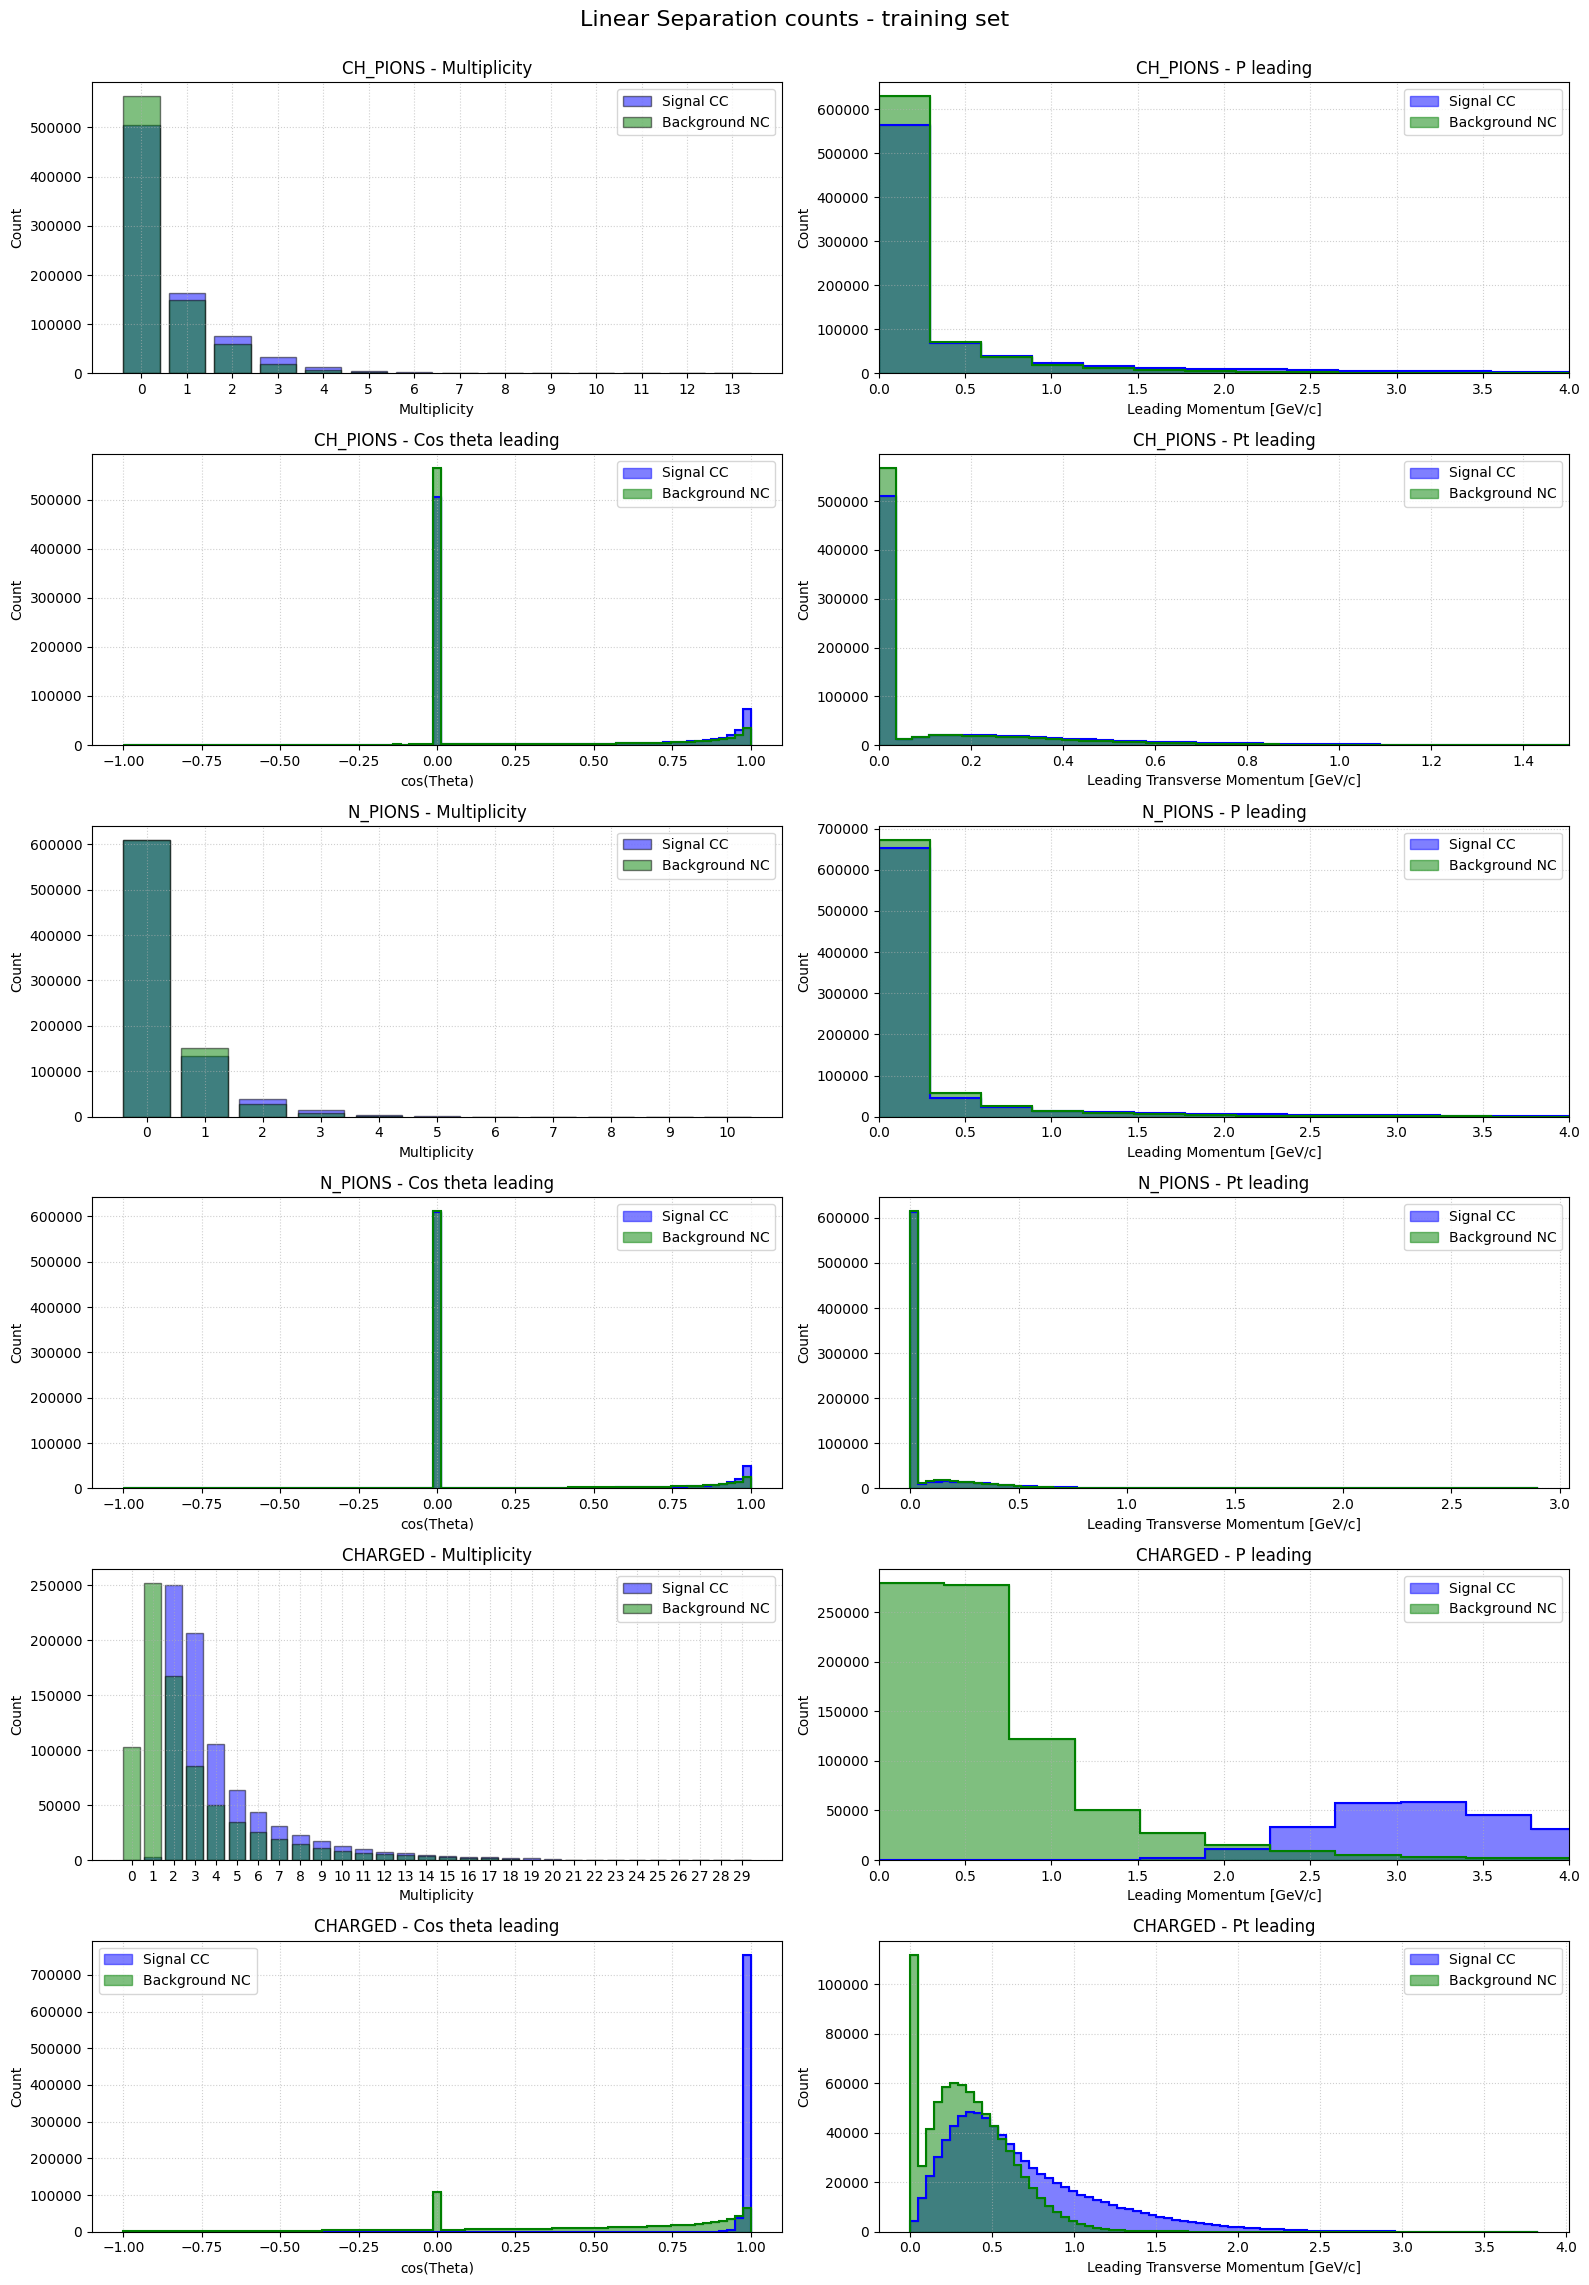

In [15]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

df_CC = df_balanced_train[df_balanced_train['CCNC'] == 1]
df_NC = df_balanced_train[df_balanced_train['CCNC'] == 0]

dfs_preprocessed = [None, df_CC, df_NC] 

fig, axes = plt.subplots(6, 2, figsize=(16, 24))

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[0, 1], density=False)
axes[0, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='cos_theta_leading', ax=axes[1, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[1, 1], density=False)
axes[1, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[2, 1], density=False)
axes[2, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='cos_theta_leading', ax=axes[3, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='pt_leading', ax=axes[3, 1], density=False)
# axes[3, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='multiplicity', ax=axes[4, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='p_leading', ax=axes[4, 1], density=False)
axes[4, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='cos_theta_leading', ax=axes[5, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='pt_leading', ax=axes[5, 1], density=False)

plt.suptitle("Linear Separation counts - training set", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


## Transforming data to tensors 

In [31]:
import analysis.scripts.preprocess_functions as prf
importlib.reload(prf)

if demo:
    batch_size=32

if not demo:
    batch_size=128

train_data = prf.tensorize_data(df_balanced_train, batch_size=batch_size)
val_data = prf.tensorize_data(df_unbalanced_val, batch_size=batch_size)
test_data = prf.tensorize_data(df_unbalanced_test, batch_size=batch_size)



## Verifying tensors-pandas coherence for the training set

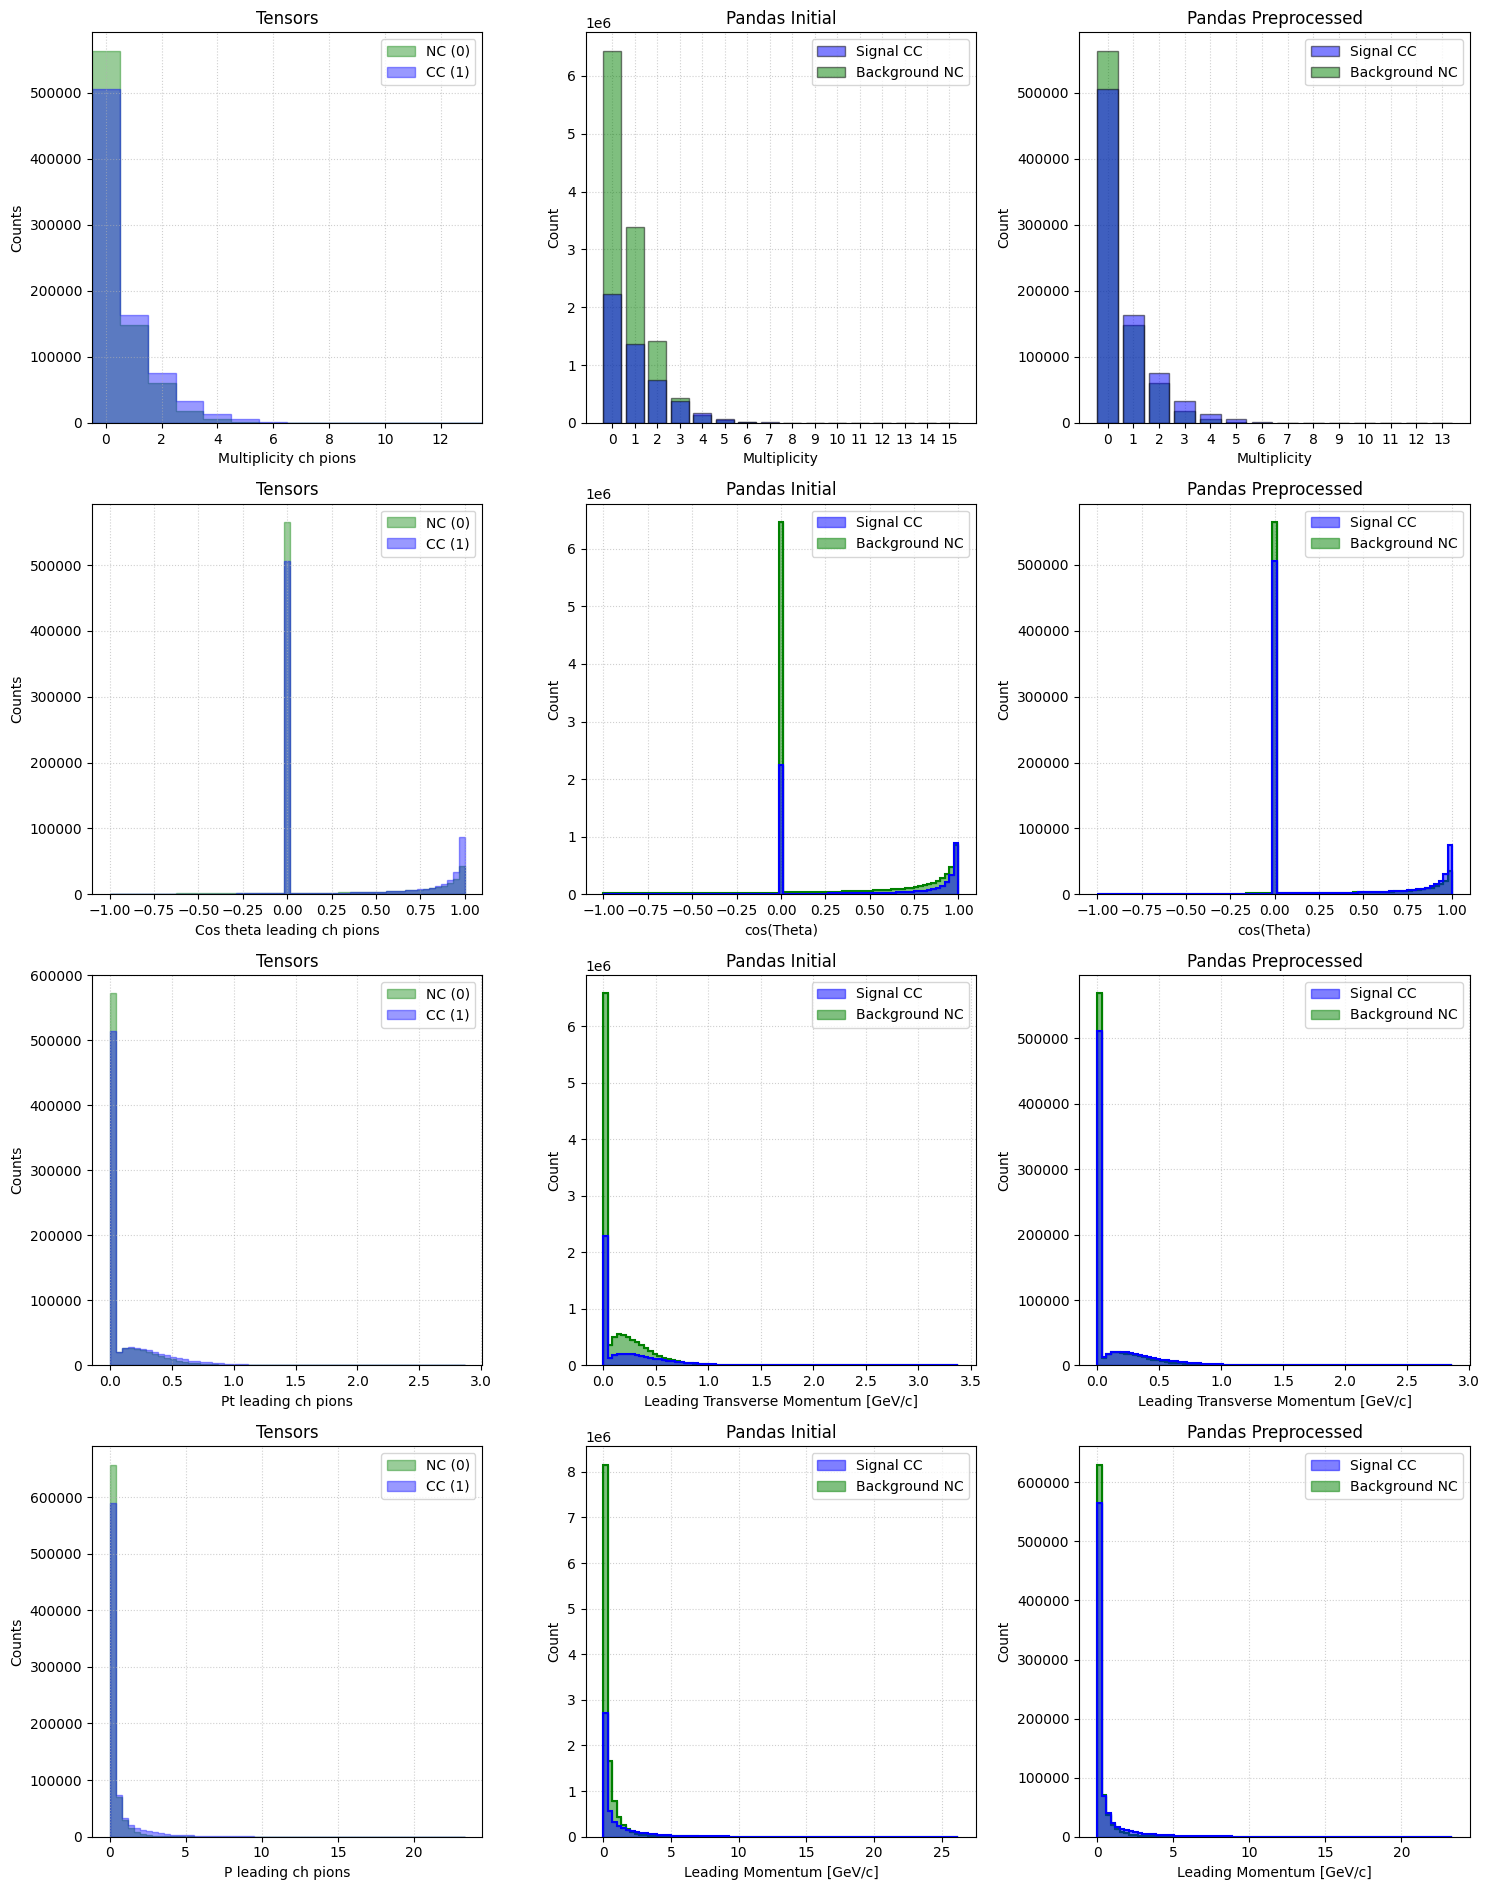

2026-05-06 11:21:45.627310: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:21:57.472114: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:22:10.594117: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:22:23.608517: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [22]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

    # 0:  'p_leading_ch_pions',
    # 1:  'pt_leading_ch_pions',
    # 2:  'cos_theta_leading_ch_pions',
    # 3:  'multiplicity_ch_pions',

df_CC_leg = df_legacy[df_legacy['CCNC'] == 1]
df_NC_leg = df_legacy[df_legacy['CCNC'] == 0]

dfs_processed = [None, df_CC_leg, df_NC_leg] 

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

pf.plot_feature_from_dataset(train_data, 3, ax=axes[0, 0]) 
axes[0,0].set_title("Tensors")     
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='multiplicity', ax=axes[0, 1], density=False)
axes[0,1].set_title("Pandas Initial")    
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 2], density=False)
axes[0,2].set_title("Pandas Preprocessed")  

pf.plot_feature_from_dataset(train_data, 2, ax=axes[1, 0]) 
axes[1,0].set_title("Tensors")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='cos_theta_leading', ax=axes[1, 1], density=False)
axes[1,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='cos_theta_leading', ax=axes[1, 2], density=False)
axes[1,2].set_title("Pandas Preprocessed")    


pf.plot_feature_from_dataset(train_data, 1, ax=axes[2, 0]) 
axes[2,0].set_title("Tensors")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='pt_leading', ax=axes[2, 1], density=False)
axes[2,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[2, 2], density=False)
axes[2,2].set_title("Pandas Preprocessed")  

pf.plot_feature_from_dataset(train_data, 0, ax=axes[3, 0]) # Neutral Leading p
axes[3,0].set_title("Tensors")   
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='p_leading', ax=axes[3, 1], density=False)
axes[3,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[3, 2], density=False)
axes[3,2].set_title("Pandas Preprocessed")  

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


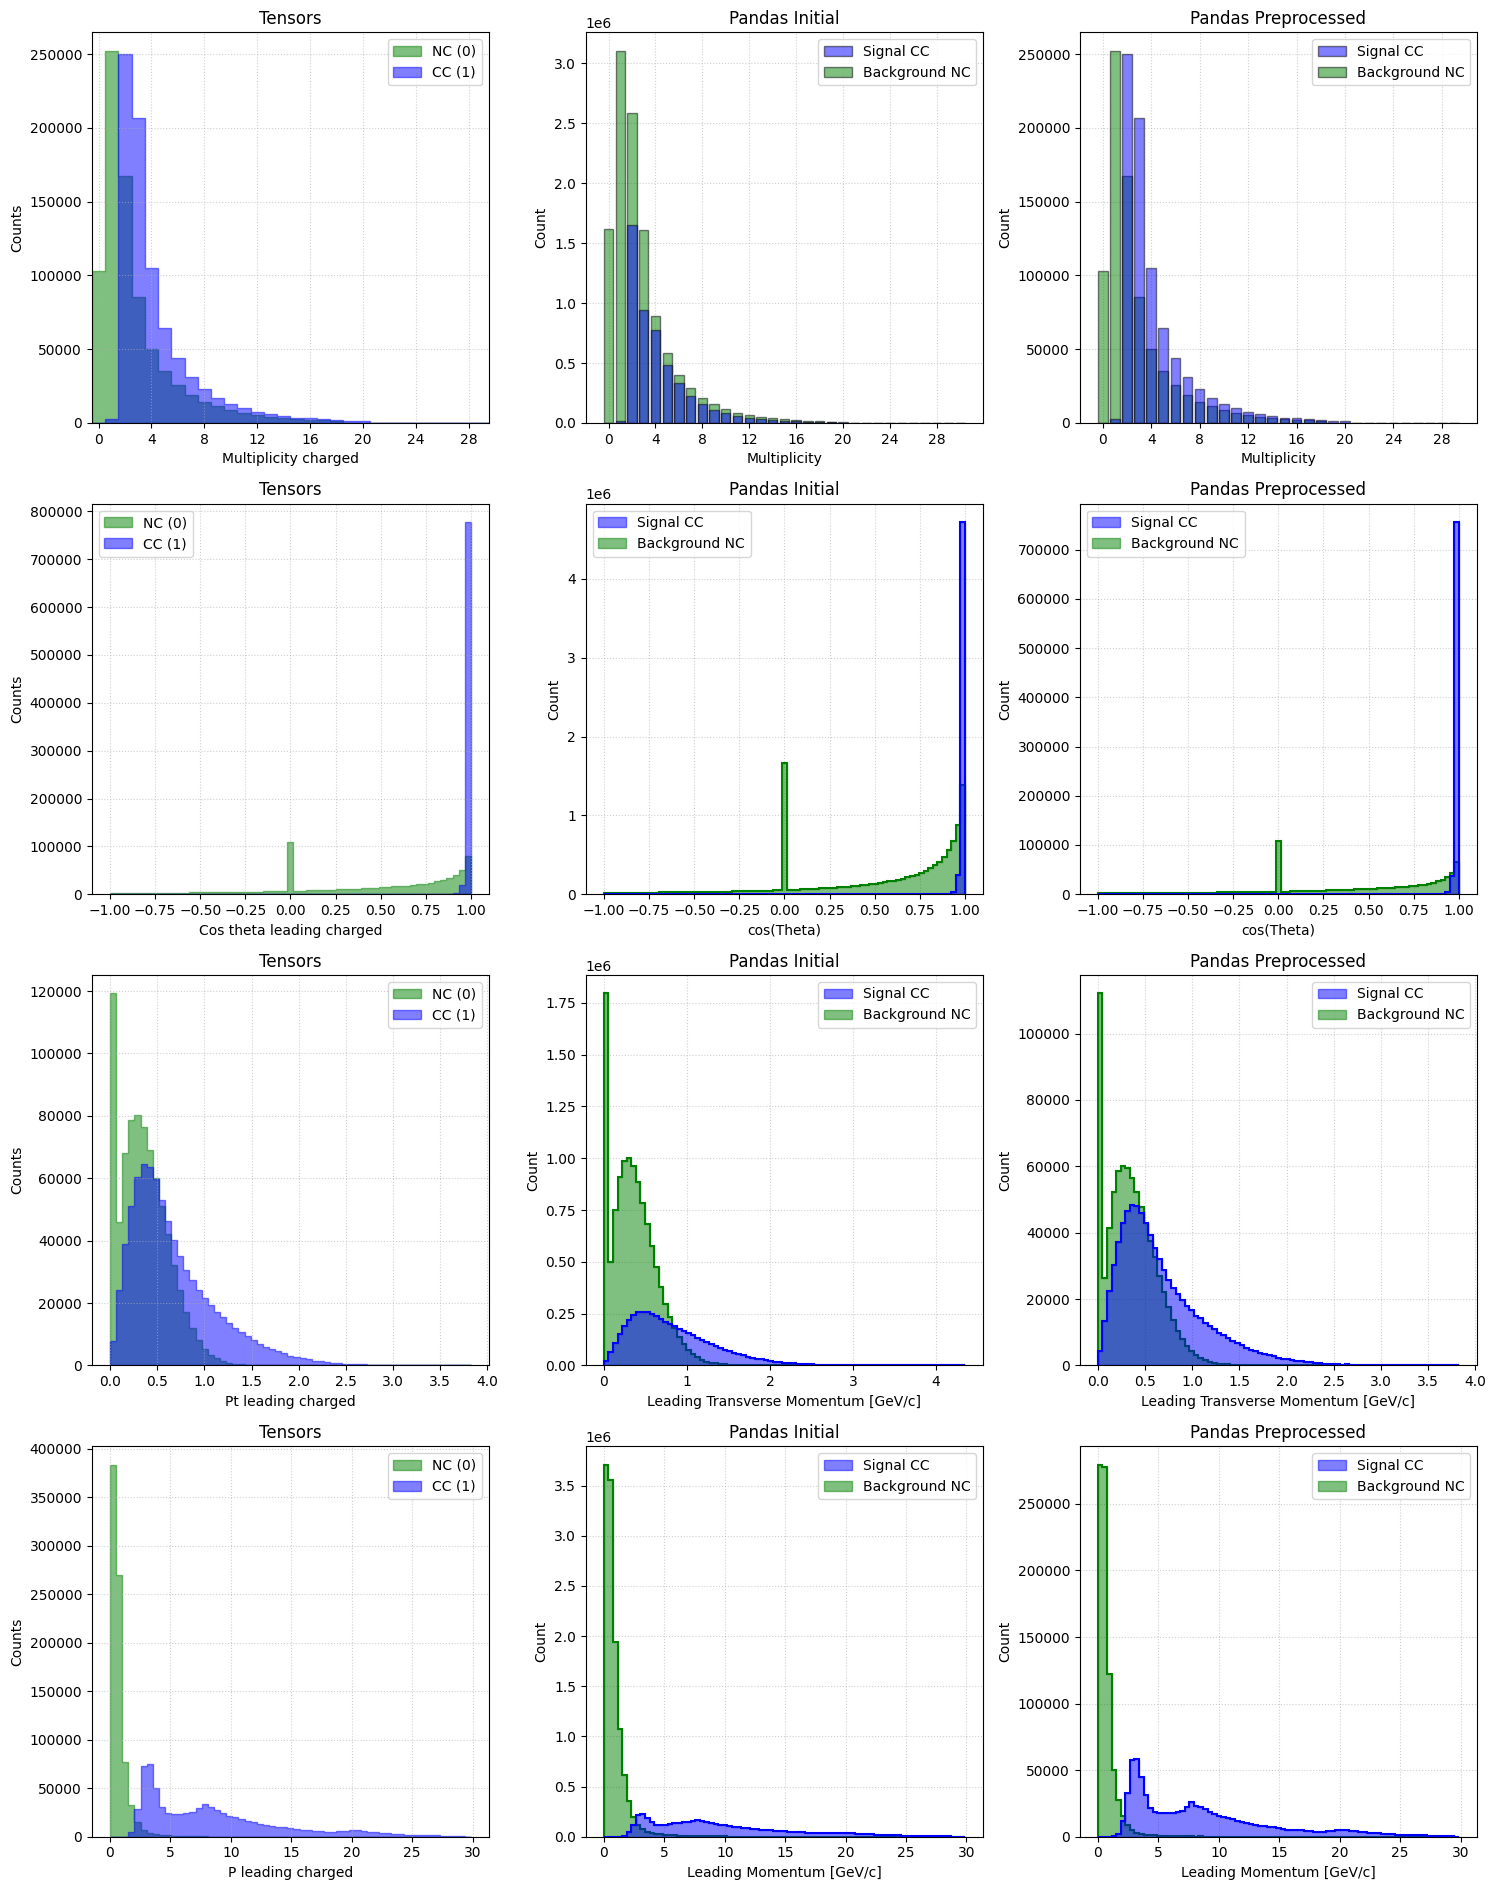

2026-05-06 11:40:37.486723: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:40:41.391779: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:40:46.781674: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:40:52.172835: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [32]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

    # 4:  'multiplicity_charged',
    # 5:  'p_leading_charged',
    # 6:  'pt_leading_charged',
    # 7:  'cos_theta_leading_charged',

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

pf.plot_feature_from_dataset(train_data, 4, ax=axes[0, 0]) 
axes[0,0].set_title("Tensors")     
pf.plot_physics_single_canva(dfs_processed, 'charged', feature='multiplicity', ax=axes[0, 1], density=False)
axes[0,1].set_title("Pandas Initial")    
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='multiplicity', ax=axes[0, 2], density=False)
axes[0,2].set_title("Pandas Preprocessed")  

pf.plot_feature_from_dataset(train_data, 7, ax=axes[1, 0]) 
axes[1,0].set_title("Tensors")    
pf.plot_physics_single_canva(dfs_processed, 'charged', feature='cos_theta_leading', ax=axes[1, 1], density=False)
axes[1,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='cos_theta_leading', ax=axes[1, 2], density=False)
axes[1,2].set_title("Pandas Preprocessed")    


pf.plot_feature_from_dataset(train_data, 6, ax=axes[2, 0]) 
axes[2,0].set_title("Tensors")    
pf.plot_physics_single_canva(dfs_processed, 'charged', feature='pt_leading', ax=axes[2, 1], density=False)
axes[2,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='pt_leading', ax=axes[2, 2], density=False)
axes[2,2].set_title("Pandas Preprocessed")  

pf.plot_feature_from_dataset(train_data, 5, ax=axes[3, 0]) # Neutral Leading p
axes[3,0].set_title("Tensors")   
pf.plot_physics_single_canva(dfs_processed, 'charged', feature='p_leading', ax=axes[3, 1], density=False)
axes[3,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'charged', feature='p_leading', ax=axes[3, 2], density=False)
axes[3,2].set_title("Pandas Preprocessed")  

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


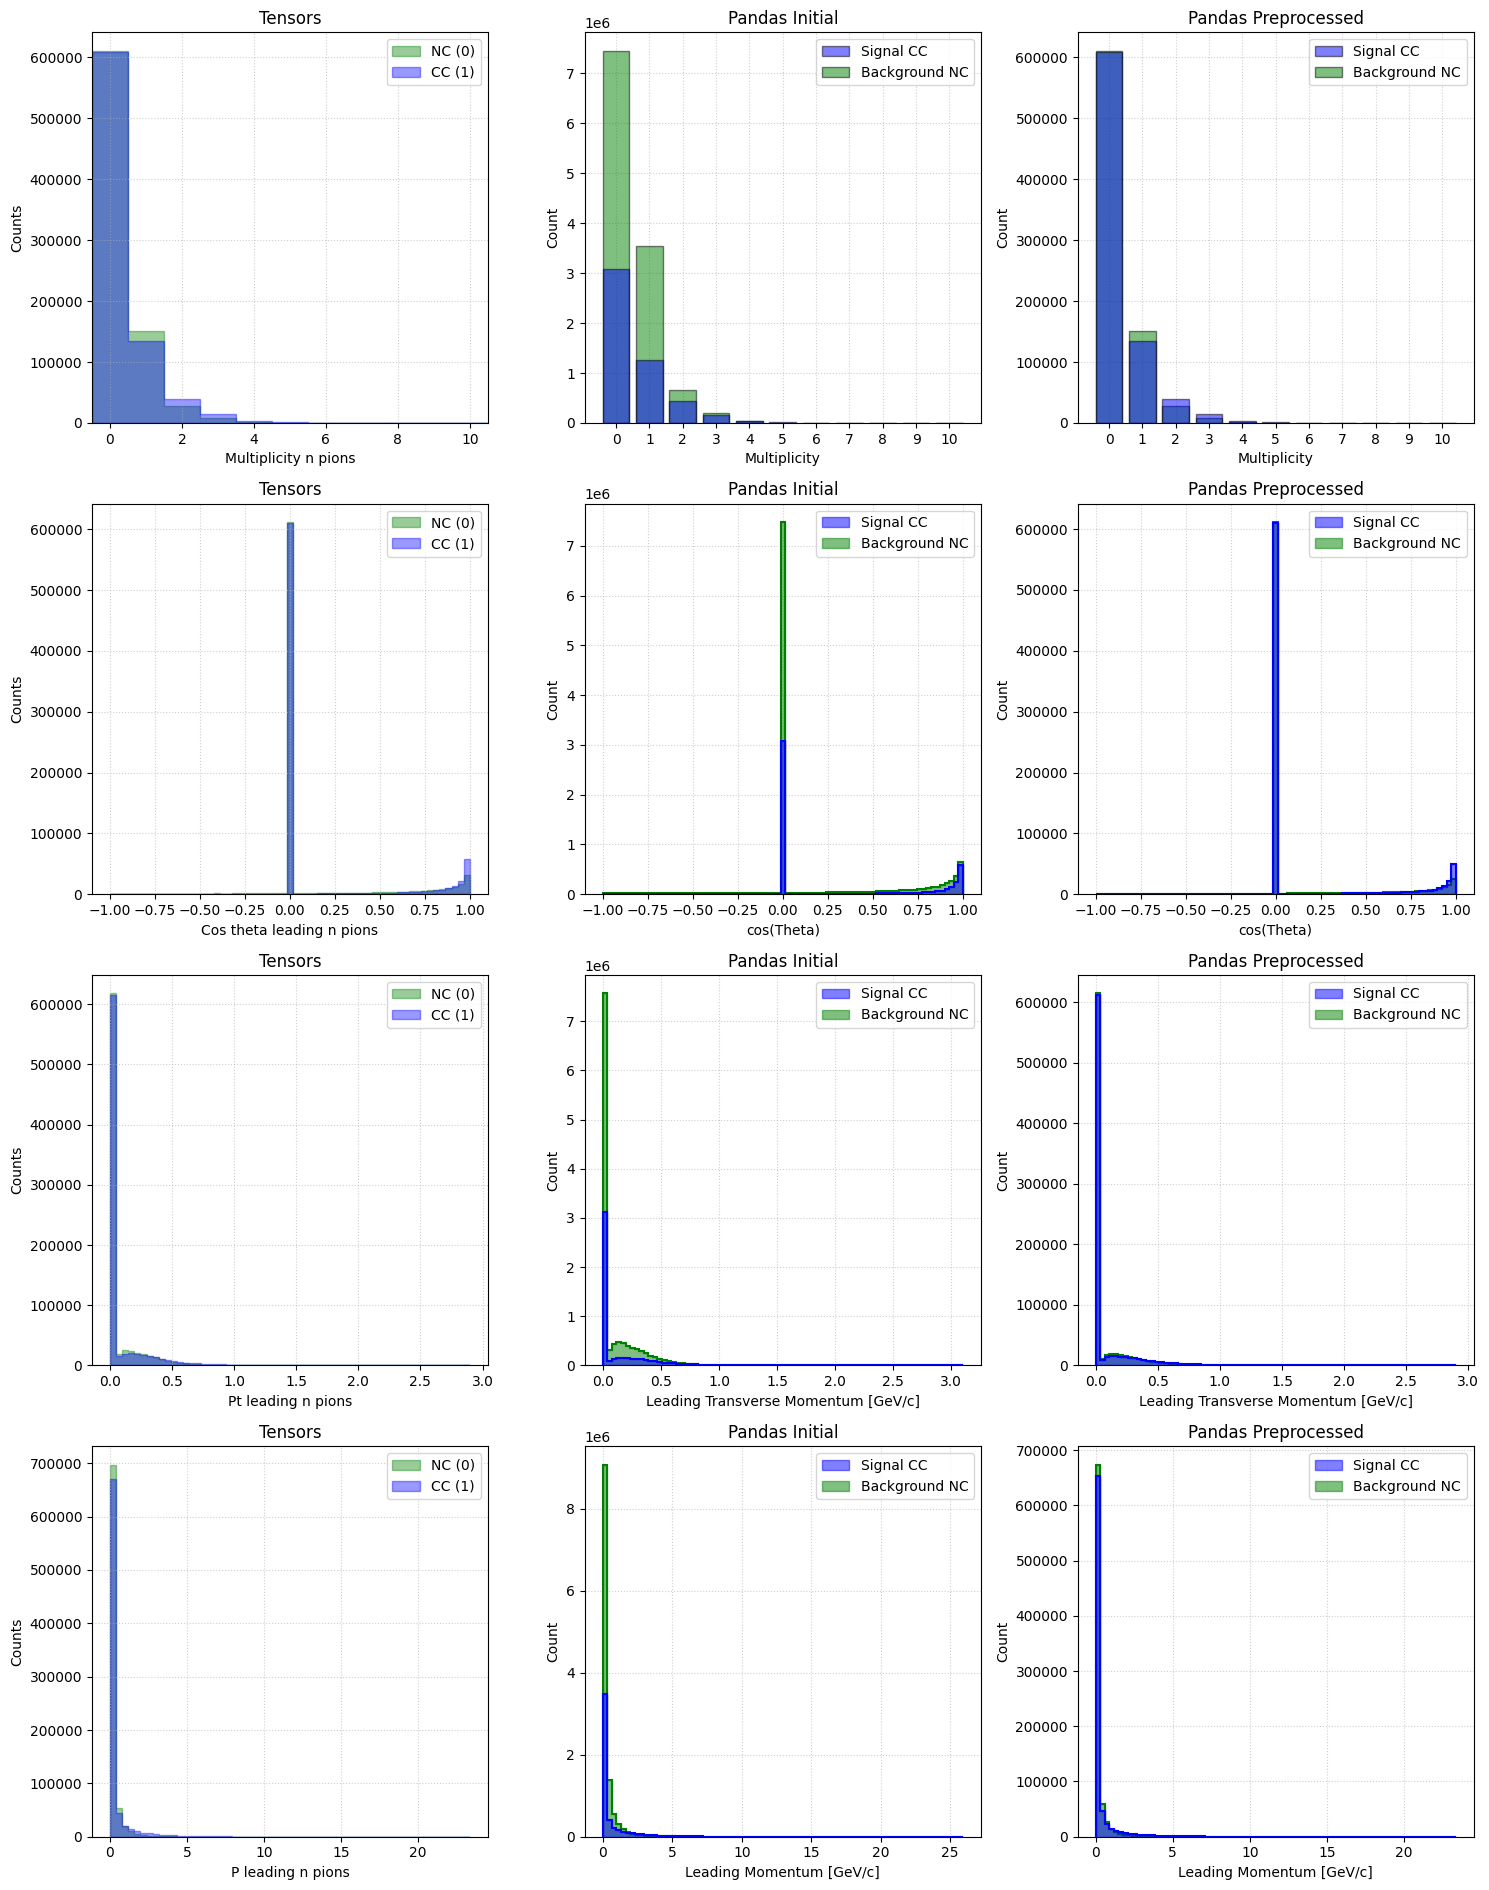

2026-05-06 11:23:35.017916: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:23:46.972252: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:23:59.876943: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 11:24:12.672060: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [24]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

    # 8:  'multiplicity_n_pions',
    # 9:  'p_leading_n_pions',
    # 10: 'pt_leading_n_pions',
    # 11: 'cos_theta_leading_n_pions'

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

pf.plot_feature_from_dataset(train_data, 8, ax=axes[0, 0]) 
axes[0,0].set_title("Tensors")     
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='multiplicity', ax=axes[0, 1], density=False)
axes[0,1].set_title("Pandas Initial")    
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[0, 2], density=False)
axes[0,2].set_title("Pandas Preprocessed")  

pf.plot_feature_from_dataset(train_data, 11, ax=axes[1, 0]) 
axes[1,0].set_title("Tensors")    
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='cos_theta_leading', ax=axes[1, 1], density=False)
axes[1,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='cos_theta_leading', ax=axes[1, 2], density=False)
axes[1,2].set_title("Pandas Preprocessed")    


pf.plot_feature_from_dataset(train_data, 10, ax=axes[2, 0]) 
axes[2,0].set_title("Tensors")    
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='pt_leading', ax=axes[2, 1], density=False)
axes[2,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='pt_leading', ax=axes[2, 2], density=False)
axes[2,2].set_title("Pandas Preprocessed")  

pf.plot_feature_from_dataset(train_data, 9, ax=axes[3, 0]) # Neutral Leading p
axes[3,0].set_title("Tensors")   
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='p_leading', ax=axes[3, 1], density=False)
axes[3,1].set_title("Pandas Initial")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[3, 2], density=False)
axes[3,2].set_title("Pandas Preprocessed")  

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()


## Model

In [33]:
#very simple 1dCNN

def getModel():
    model = tf.keras.Sequential([
        # tf.keras.Input(shape=(8, 1)),
        tf.keras.Input(shape=(12,1)), #12 features, 1 label, CNN need 3D tensors
        #one layer for permutation of the input - dense
        tf.keras.layers.BatchNormalization(),


        #bigger brain to develop
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        
        tf.keras.layers.Flatten(), #global pooling?

        #regularization to add
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name='1dCNN_proto')
    return model

model_1dCNN = getModel()

model_1dCNN.summary()   


Model: "1dCNN_proto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 12, 1)          │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 12, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 12, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         6,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,413 (36.77 KB)

 Trainable params: 9,411 (36.76 KB)

 Non-trainable params: 2 (8.00 B)

## Training

In [36]:
import analysis.scripts.system_functions as sf
importlib.reload(sf)

metrics = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    # FP rate 
    tf.keras.metrics.Precision(name='precision'),
    # TP rate 
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]

#####
nEpochs = 10
initial_learning_rate = 3E-4
#batch_size defined when creating the datasets



if not save:
    callbacks = [] #for testing disable checkpoints

if save:
    current_run_dir = sf.get_experiment_folder("1DCNN_testing")
    checkpoint_filepath = os.path.join(current_run_dir, 'checkpoint_epoch_{epoch:02d}.weights.h5')
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, save_weights_only=True, monitor='val_auc', mode='max', save_best_only=True, verbose=1)
    final_model_path = os.path.join(current_run_dir, "final_model_full.keras")


if save:
    callbacks = [model_checkpoint_callback]


model_1dCNN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
              loss='binary_crossentropy', metrics=metrics)

In [40]:
history = model_1dCNN.fit(
    train_data,
    validation_data=val_data,
    epochs=nEpochs,
    callbacks=callbacks,
    verbose=1
)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Epoch 1/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 96s 8ms/step - accuracy: 0.9890 - auc: 0.9987 - loss: 0.0324 - precision: 0.9854 - recall: 0.9927 - val_accuracy: 0.9128 - val_auc: 0.8314 - val_loss: 0.4275 - val_precision: 0.6388 - val_recall: 0.3669
Epoch 2/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 92s 7ms/step - accuracy: 0.9893 - auc: 0.9988 - loss: 0.0315 - precision: 0.9858 - recall: 0.9929 - val_accuracy: 0.9133 - val_auc: 0.8204 - val_loss: 0.4638 - val_precision: 0.6435 - val_recall: 0.3673
Epoch 3/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 91s 7ms/step - accuracy: 0.9895 - auc: 0.9988 - loss: 0.0311 - precision: 0.9860 - recall: 0.9931 - val_accuracy: 0.9130 - val_auc: 0.8150 - val_loss: 0.4782 - val_precision: 0.6455 - val_recall: 0.3581
Epoch 4/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 91s 7ms/step - accuracy: 0.9896 - auc: 0.9988 - loss: 0.0308 - precision: 0.9861 - recall: 0.9932 - val_accuracy: 0.9131 - val_auc: 0.8157 - val_loss: 0.4854 - val_precision: 0.6477 - val_recall: 0.3553
Epoch 5/10
1

COMET INFO: Message(s) of type 'metric_msg' were throttled due to backend limits and will be retried after: 2026-05-06T11:57:01.127659 (in 26 seconds)


 6055/12500 ━━━━━━━━━━━━━━━━━━━━ 1:00 9ms/step - accuracy: 0.9898 - auc: 0.9988 - loss: 0.0301 - precision: 0.9863 - recall: 0.9935

COMET INFO: Message(s) of type 'metric_msg' were throttled due to backend limits and will be retried after: 2026-05-06T11:57:45.412409 (in 39 seconds)


...

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 96s 8ms/step - accuracy: 0.9898 - auc: 0.9989 - loss: 0.0301 - precision: 0.9863 - recall: 0.9934 - val_accuracy: 0.9133 - val_auc: 0.8078 - val_loss: 0.5100 - val_precision: 0.6547 - val_recall: 0.3465
Epoch 10/10
 3869/12500 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - accuracy: 0.9899 - auc: 0.9989 - loss: 0.0299 - precision: 0.9865 - recall: 0.9935

COMET INFO: Message(s) of type 'metric_msg' were throttled due to backend limits and will be retried after: 2026-05-06T12:00:45.224844 (in 39 seconds)


10569/12500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9898 - auc: 0.9989 - loss: 0.0300 - precision: 0.9864 - recall: 0.9934

COMET INFO: Message(s) of type 'metric_msg' were throttled due to backend limits and will be retried after: 2026-05-06T12:01:30.231754 (in 39 seconds)


12500/12500 ━━━━━━━━━━━━━━━━━━━━ 96s 8ms/step - accuracy: 0.9898 - auc: 0.9989 - loss: 0.0301 - precision: 0.9864 - recall: 0.9934 - val_accuracy: 0.9131 - val_auc: 0.8071 - val_loss: 0.5106 - val_precision: 0.6545 - val_recall: 0.3444


## Comet Exp Tracking

In [39]:
if track:
  experiment = comet_ml.start(
    api_key="8fJ8LDvz6YAWkbOxeK3ibVvsA",
    project_name="1dcnn-dune",
    workspace="grzegorz-j-drzejowski"
  )


  hyper_params = {
    "learning_rate": initial_learning_rate,
    "steps": nEpochs,
    "batch_size": batch_size,
  }

  experiment.log_parameters(hyper_params)


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/grzegorz-j-drzejowski/1dcnn-dune/41df3938a5bf4735836afecd70530cf6



In [41]:
if track:
    experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : prior_prawn_3427
COMET INFO:     url                   : https://www.comet.com/grzegorz-j-drzejowski/1dcnn-dune/41df3938a5bf4735836afecd70530cf6
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [10]                   : (0.9890249967575073, 0.9897387623786926)
COMET INFO:     auc [10]                        : (0.998730480670929, 0.9988598823547363)
COMET INFO:     batch_accuracy [12500]          : (0.9879261255264282, 1.0)
COMET INFO:     batch_auc [12500]               : (0.9982819557189941, 1.0000001192092896)
COMET INFO:     batch_loss [12500]              : (0.012396249920129776, 0.03803305700421333)
COMET INFO:     batch_precisi

## Save model

In [26]:
accept_model = 0
if accept_model:
    #optionally save the model explicitly (for good performing models to seperate them)
    os.makedirs("models", exist_ok=True)
    path = "models/1DCNN.keras"
    model_1dCNN.save(path.format(epoch=nEpochs))

    print(f"Model saved successfully to {path.format(epoch=nEpochs)}")

## Load Model

In [27]:
load_model = 0
if load_model:
    #wczytanie modelu
    nEpochsSaved = nEpochs

    checkpoint_path = "models/1DCNN.keras"
    model_load_ = tf.keras.models.load_model(checkpoint_path.format(epoch=nEpochsSaved))

    model_load_.evaluate(val_data)
    # model_1dCNN.evaluate(val_data)

In [28]:
load_checkpoint = 0
if load_checkpoint:

    run_folder = "checkpoints/2026-04-28_1DCNN_testing(1)/" # selecting folder
    epoch_to_load = 15

    model_load = getModel() 
    weights_path = os.path.join(run_folder, f"checkpoint_epoch_{epoch_to_load:02d}.weights.h5")

    # load the weights into the architecture
    if os.path.exists(weights_path):
        print(f"Loading weights from: {weights_path}")
        model_load.load_weights(weights_path)
        
        # 5. Compile is REQUIRED before evaluation to define the loss/metrics
        model_load.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3E-4),
            loss='binary_crossentropy', metrics=metrics)
        
        # 6. Evaluate
        val_loss = model_load.evaluate(val_data)
        print(f"\n--- Evaluation Results ---")
        print(f"Epoch {epoch_to_load} Validation Loss: {val_loss:.6f}")
    else:
        print(f"Error: File not found at {weights_path}")

## Evaluation

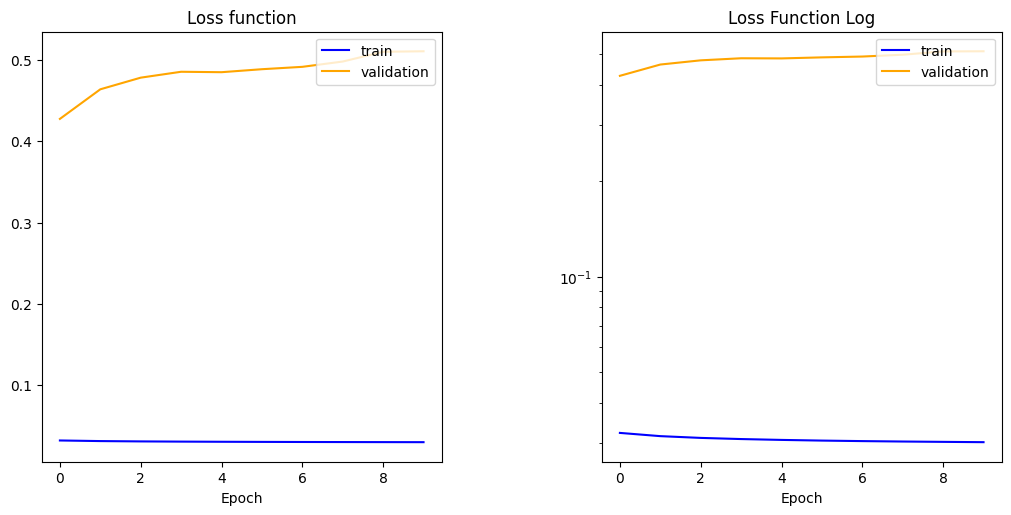

In [42]:
# eval training 

#add plotting podklas
# add CM and other metrics

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

pf.plotTrainHistory(history)

In [43]:
# 1. Get predictions and flatten them to 1D
train_preds = model_1dCNN.predict(train_data).flatten()
val_preds = model_1dCNN.predict(val_data).flatten()
test_preds = model_1dCNN.predict(test_data).flatten()

df_balanced_train['Prob_is_CC'] = train_preds
df_unbalanced_val['Prob_is_CC'] = val_preds
df_unbalanced_test['Prob_is_CC'] = test_preds

# 3. Decision: 1 = Predicted CC, 0 = Predicted NC
df_balanced_train['NN_Decision_CC'] = (train_preds > 0.5).astype(int)
df_unbalanced_val['NN_Decision_CC'] = (val_preds > 0.5).astype(int)
df_unbalanced_test['NN_Decision_CC'] = (test_preds > 0.5).astype(int)


  147/12500 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step
3856/3856 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step
3856/3856 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step


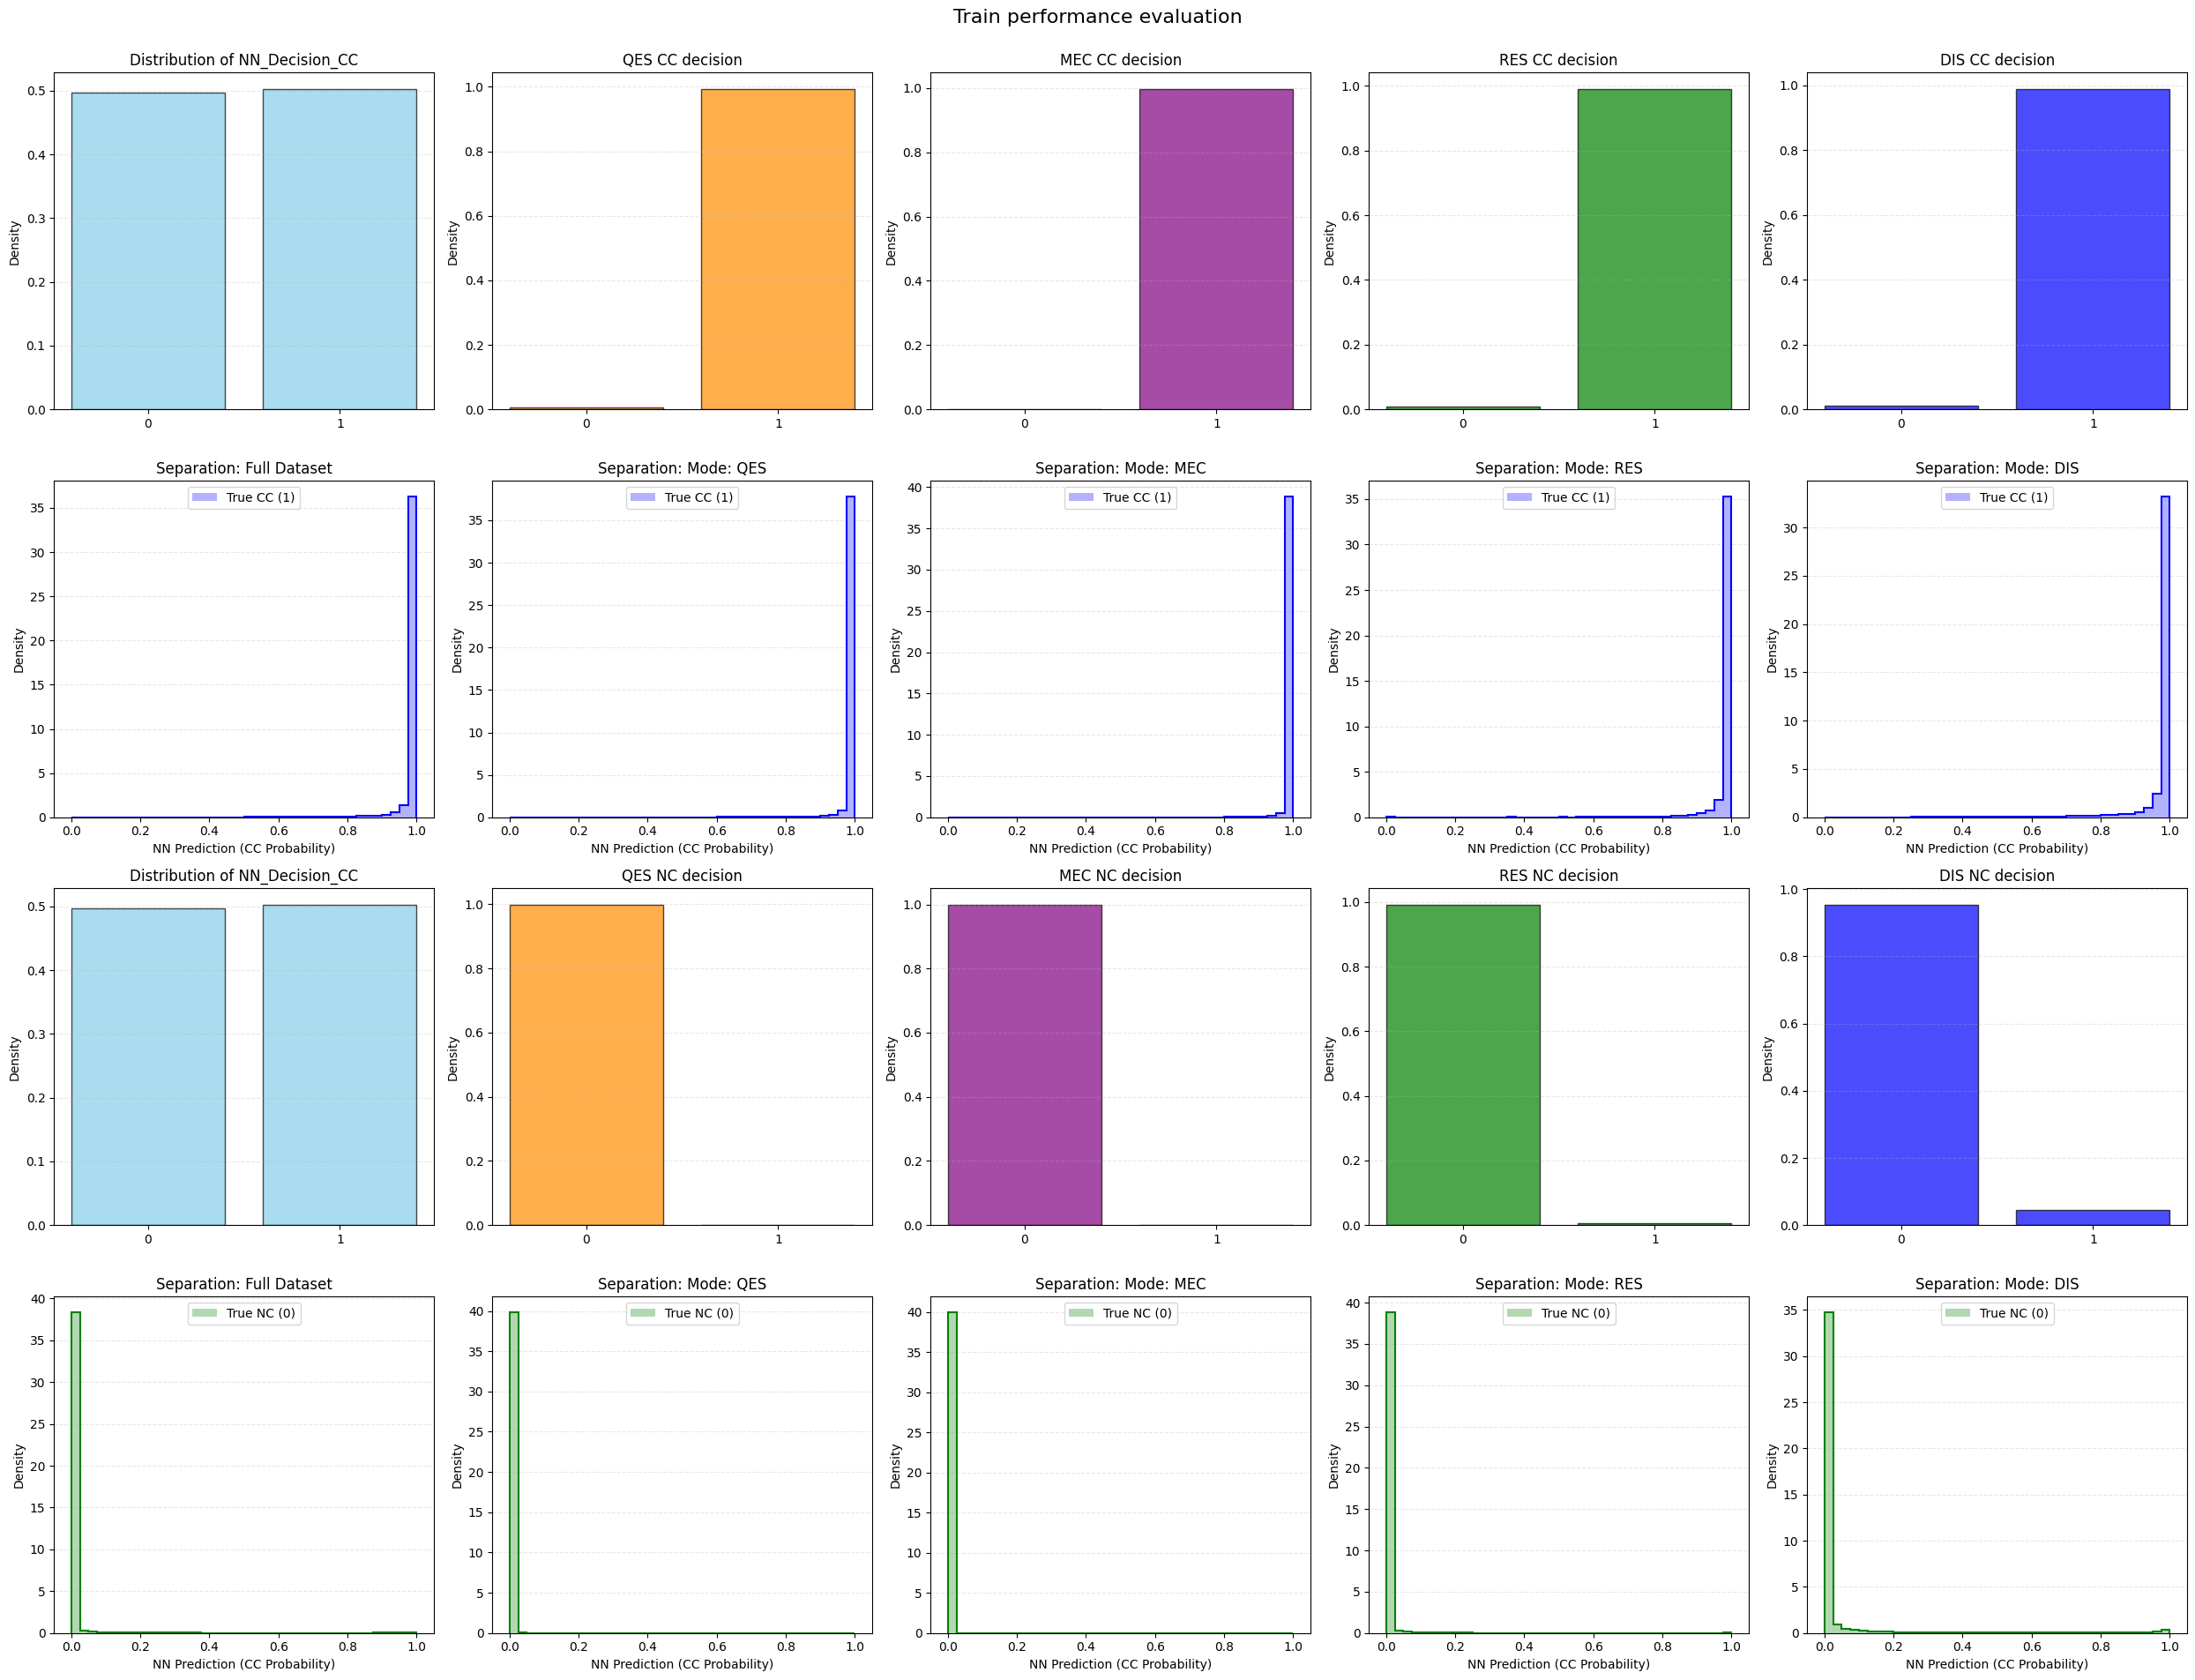

In [44]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=1, int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=1, int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=0, int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter=0, int_filter='DIS', ax=axes[3,4], density=True, color='blue')

plt.suptitle("Train performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()



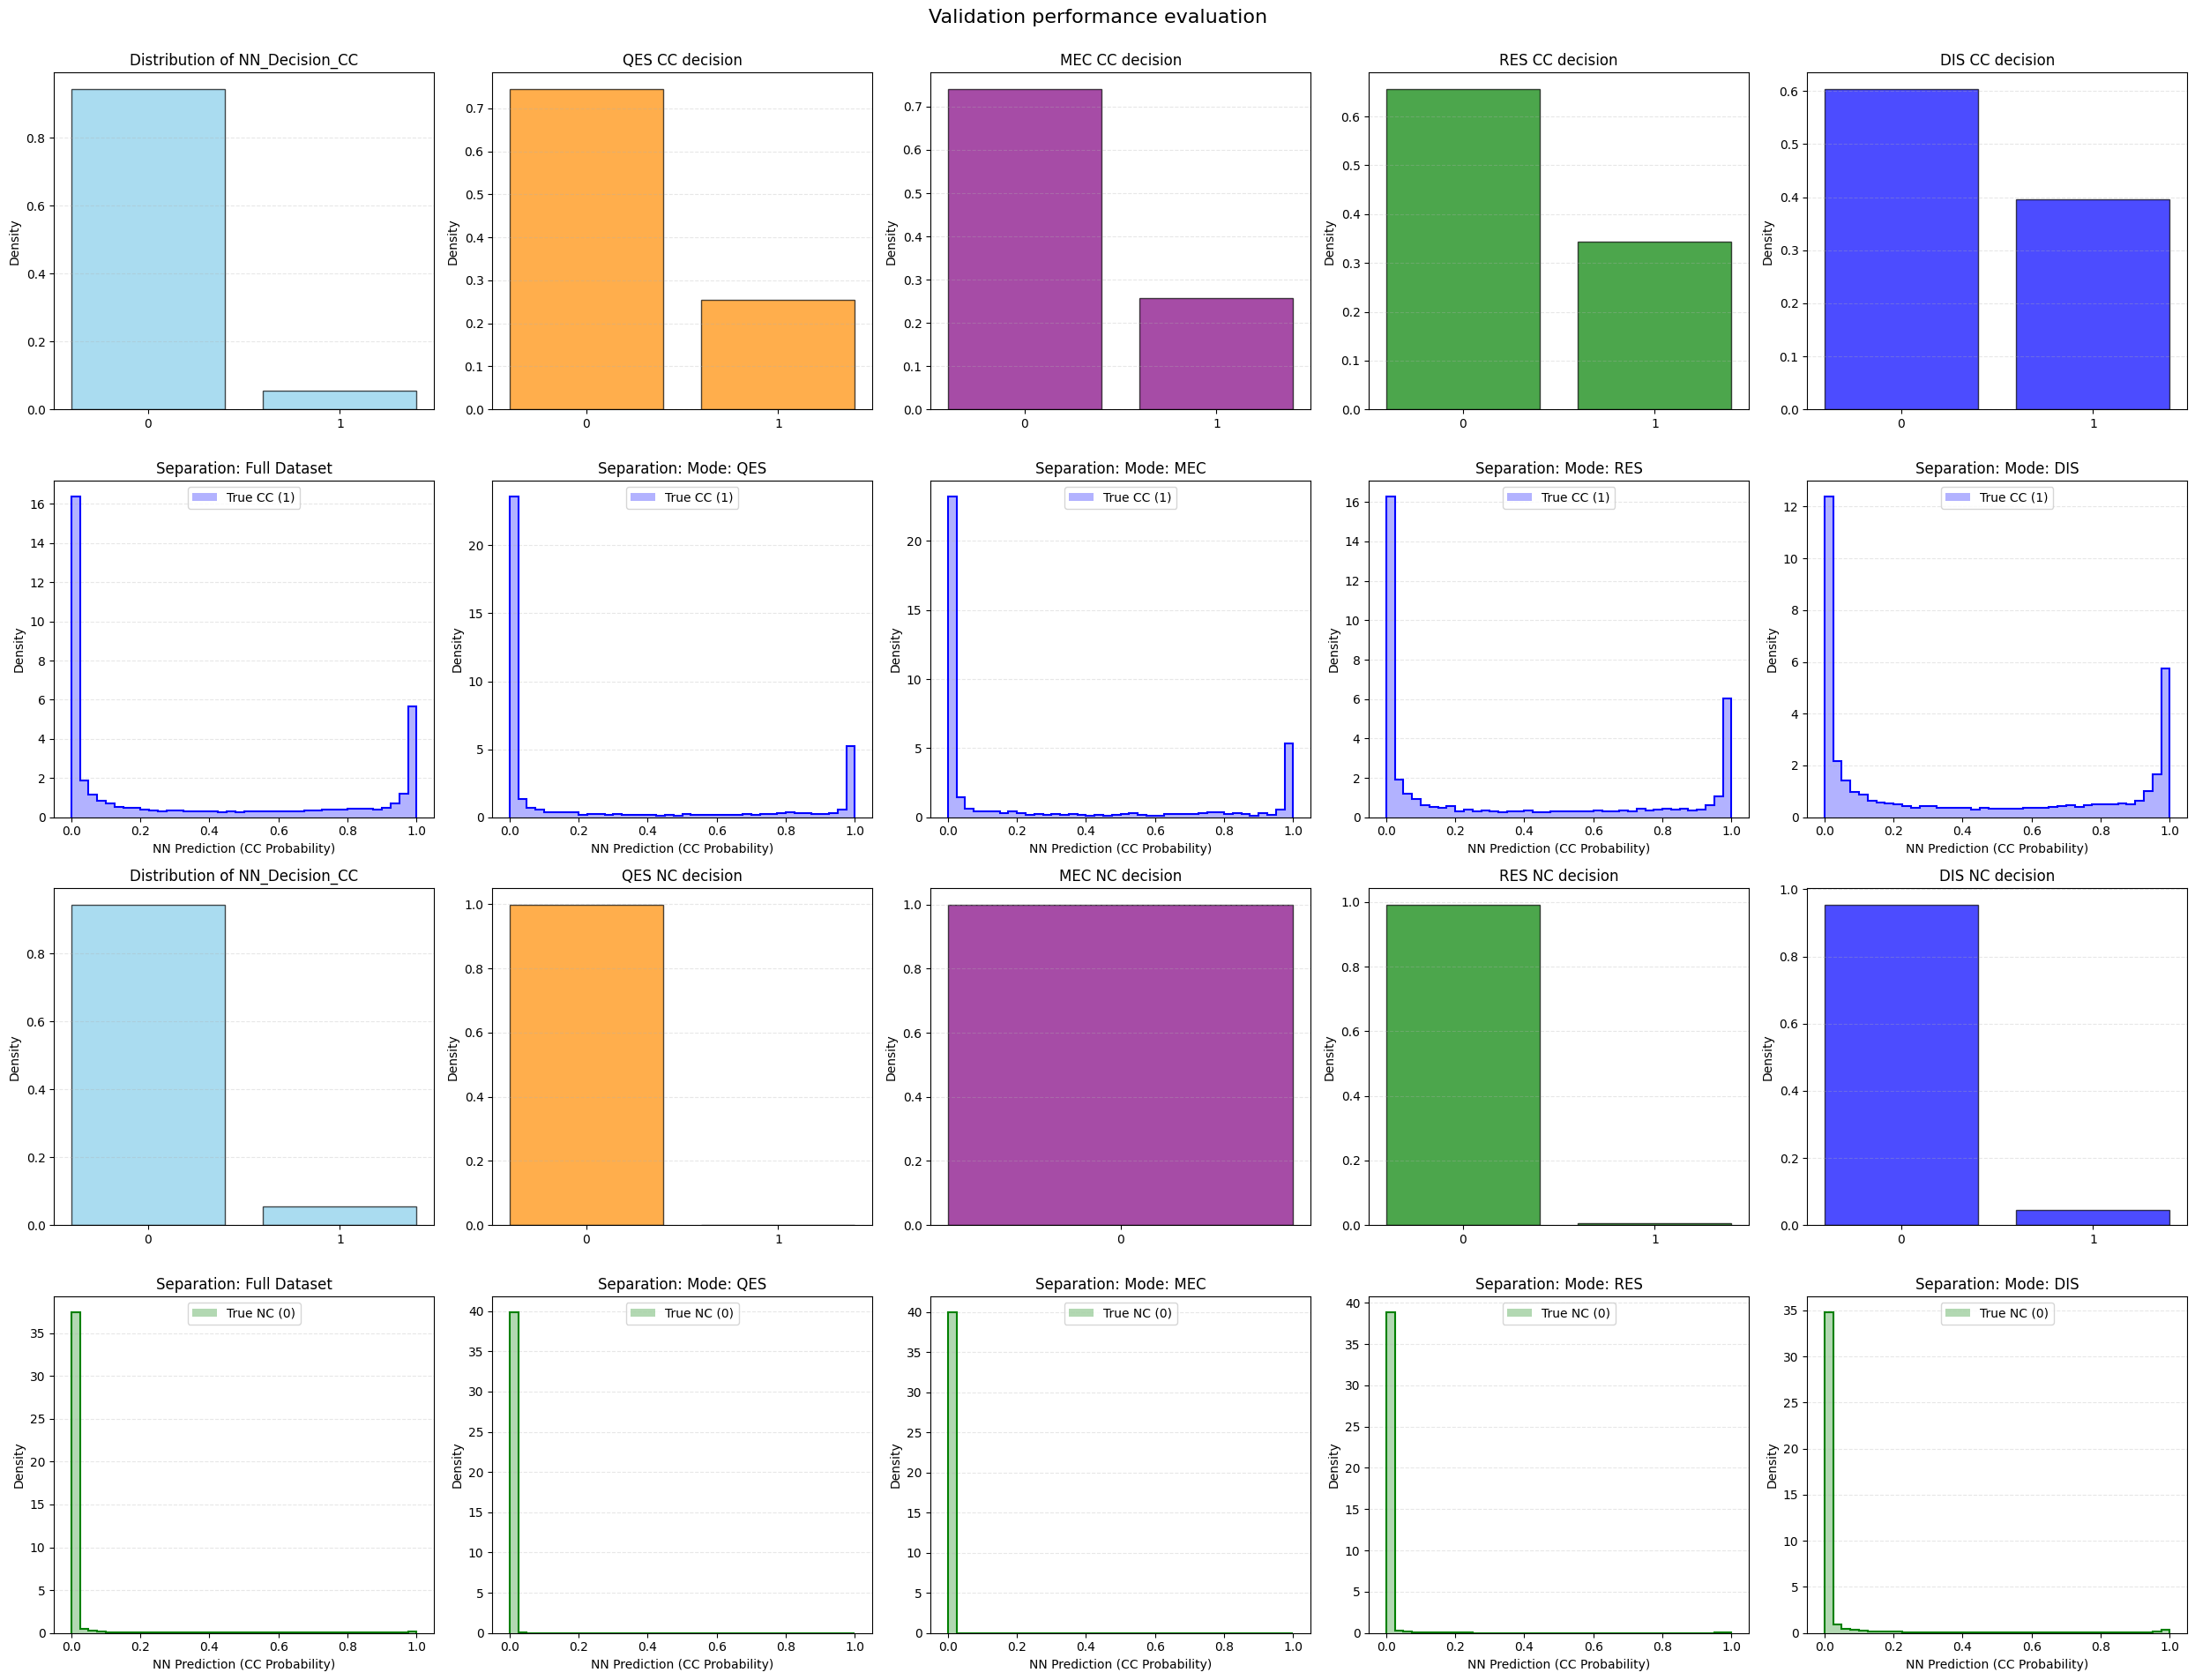

In [45]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=1, int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=1, int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_unbalanced_val, column='NN_Decision_CC', ccnc_filter=0, int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_val, column='Prob_is_CC', ccnc_filter=0, int_filter='DIS', ax=axes[3,4], density=True, color='blue')

plt.suptitle("Validation performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()



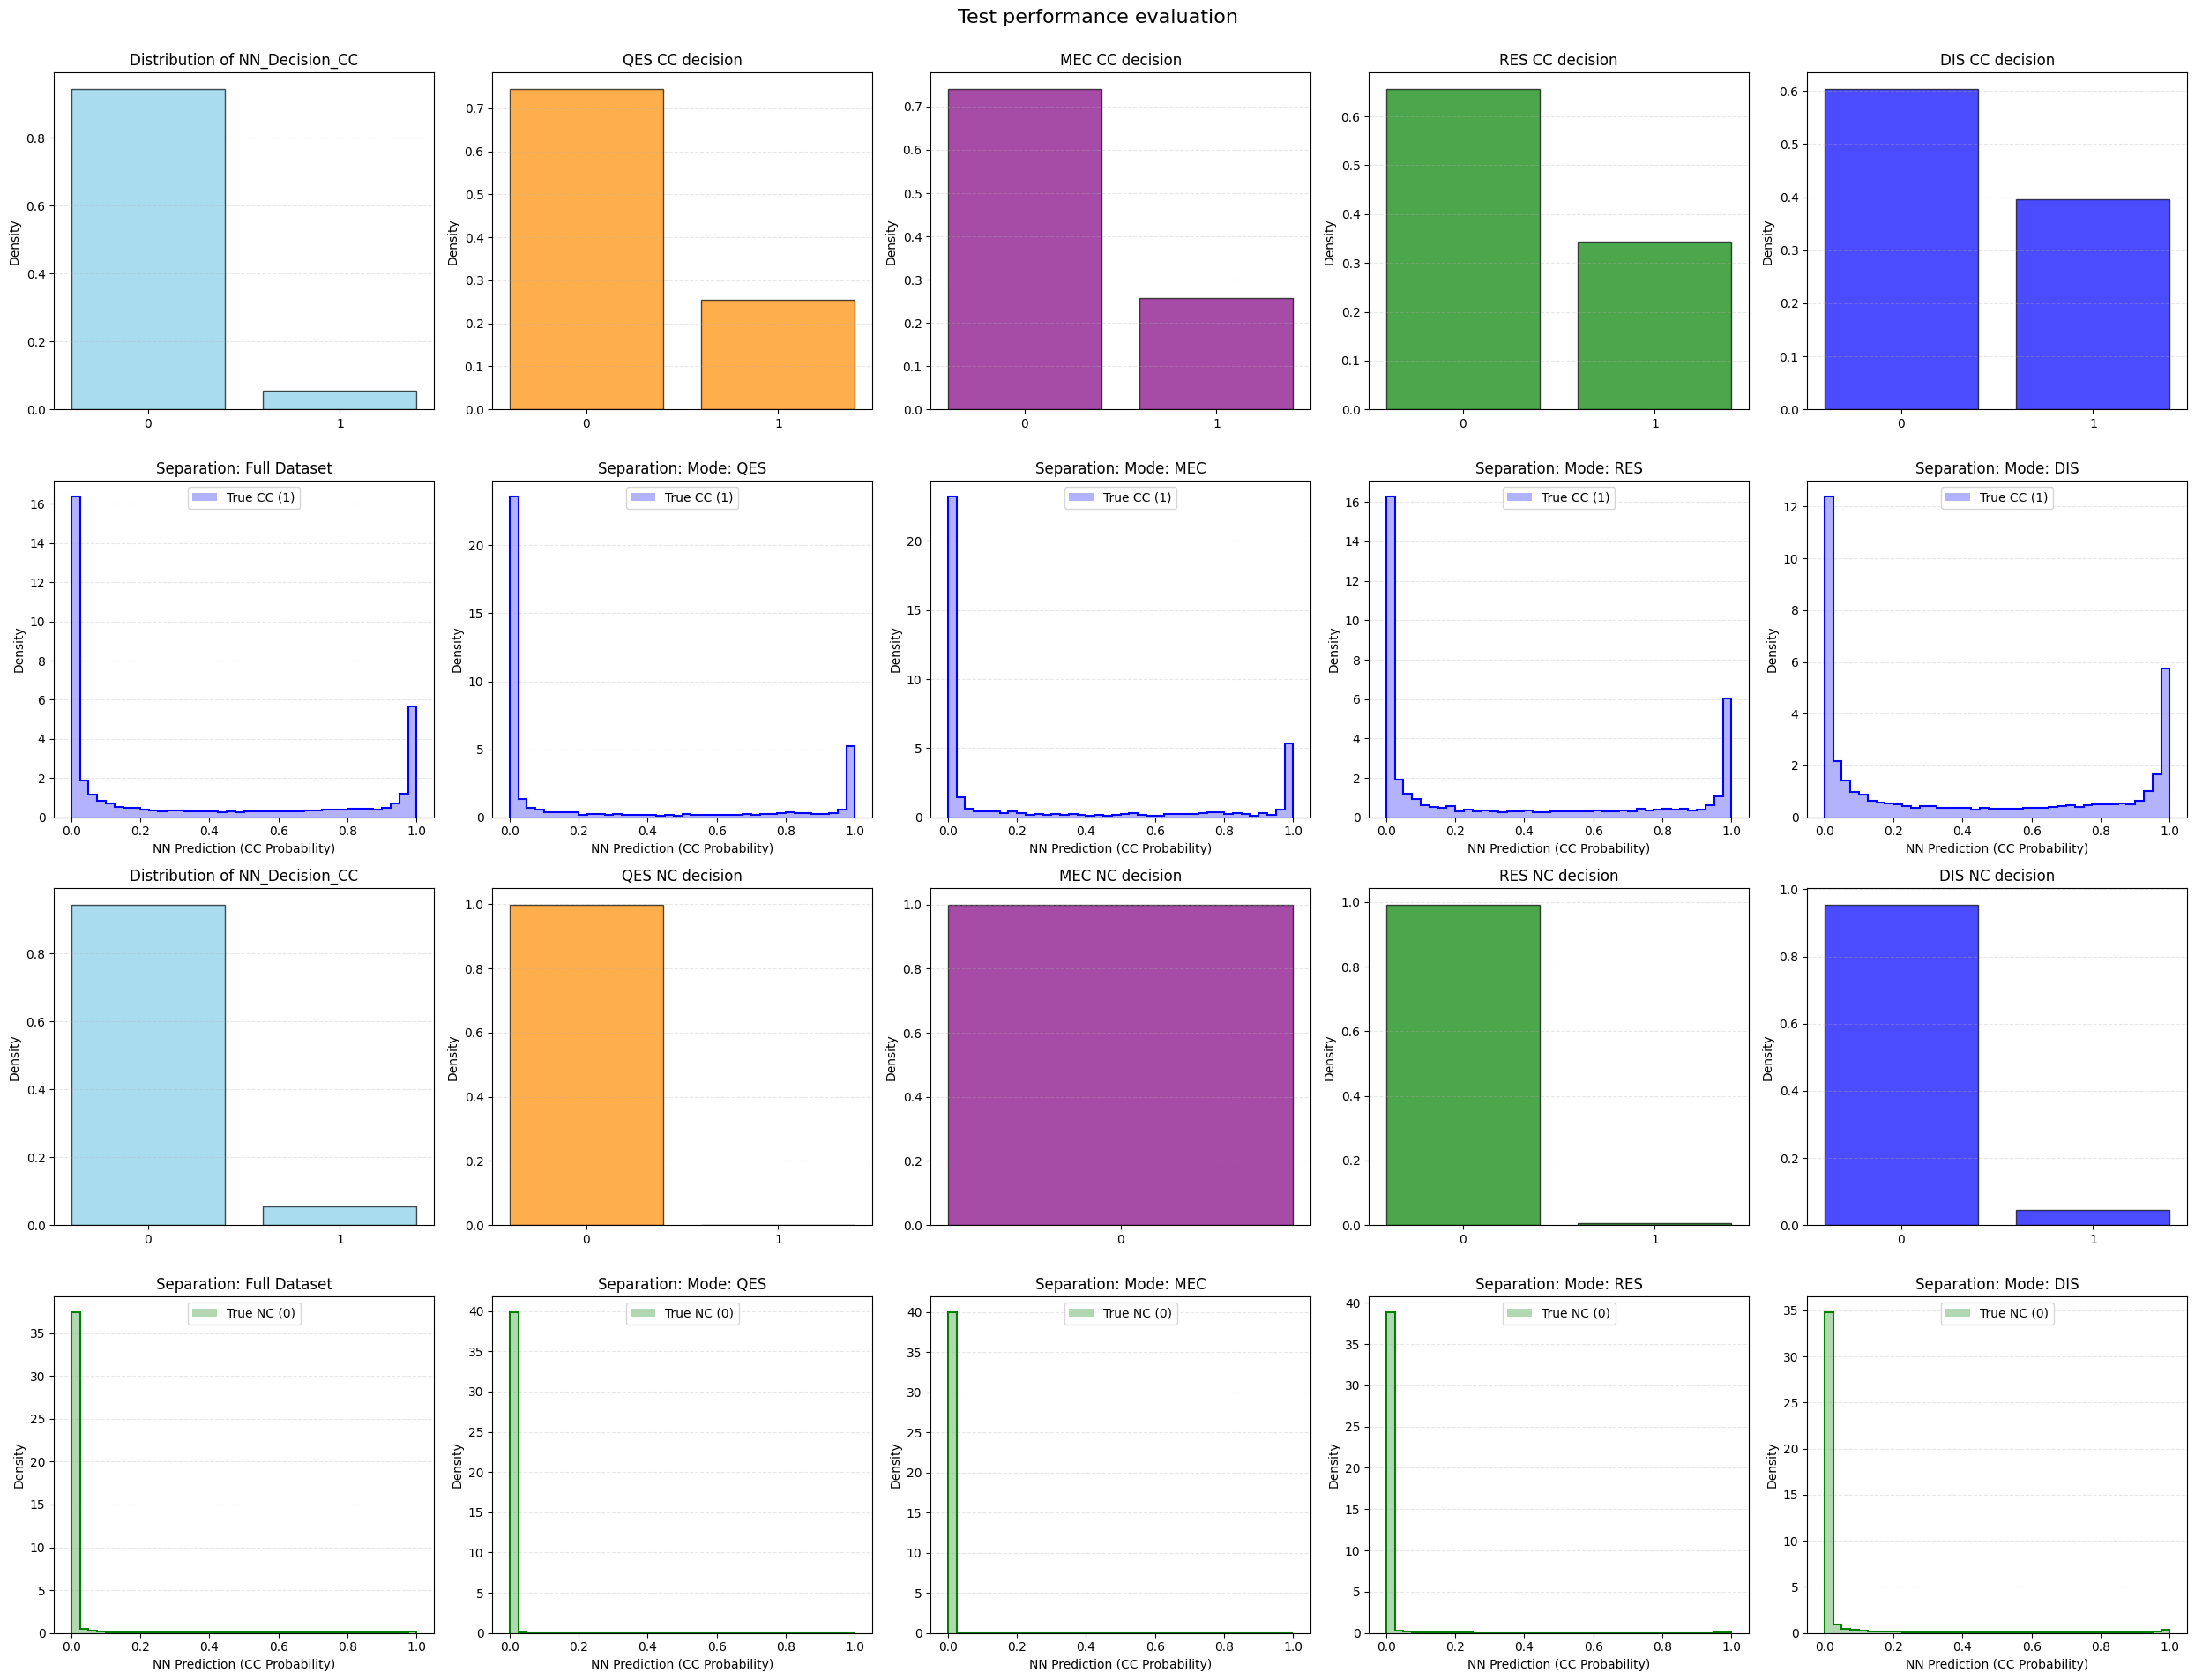

In [46]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=1, int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=1, int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_unbalanced_test, column='NN_Decision_CC', ccnc_filter=0, int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_unbalanced_test, column='Prob_is_CC', ccnc_filter=0, int_filter='DIS', ax=axes[3,4], density=True, color='blue')

plt.suptitle("Test performance evaluation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
# rect=[left, bottom, right, top] in normalized 0-1 coordinates
plt.show()



Training ROC AUC: 0.9991
Validation ROC AUC: 0.9026
Test ROC AUC: 0.9026


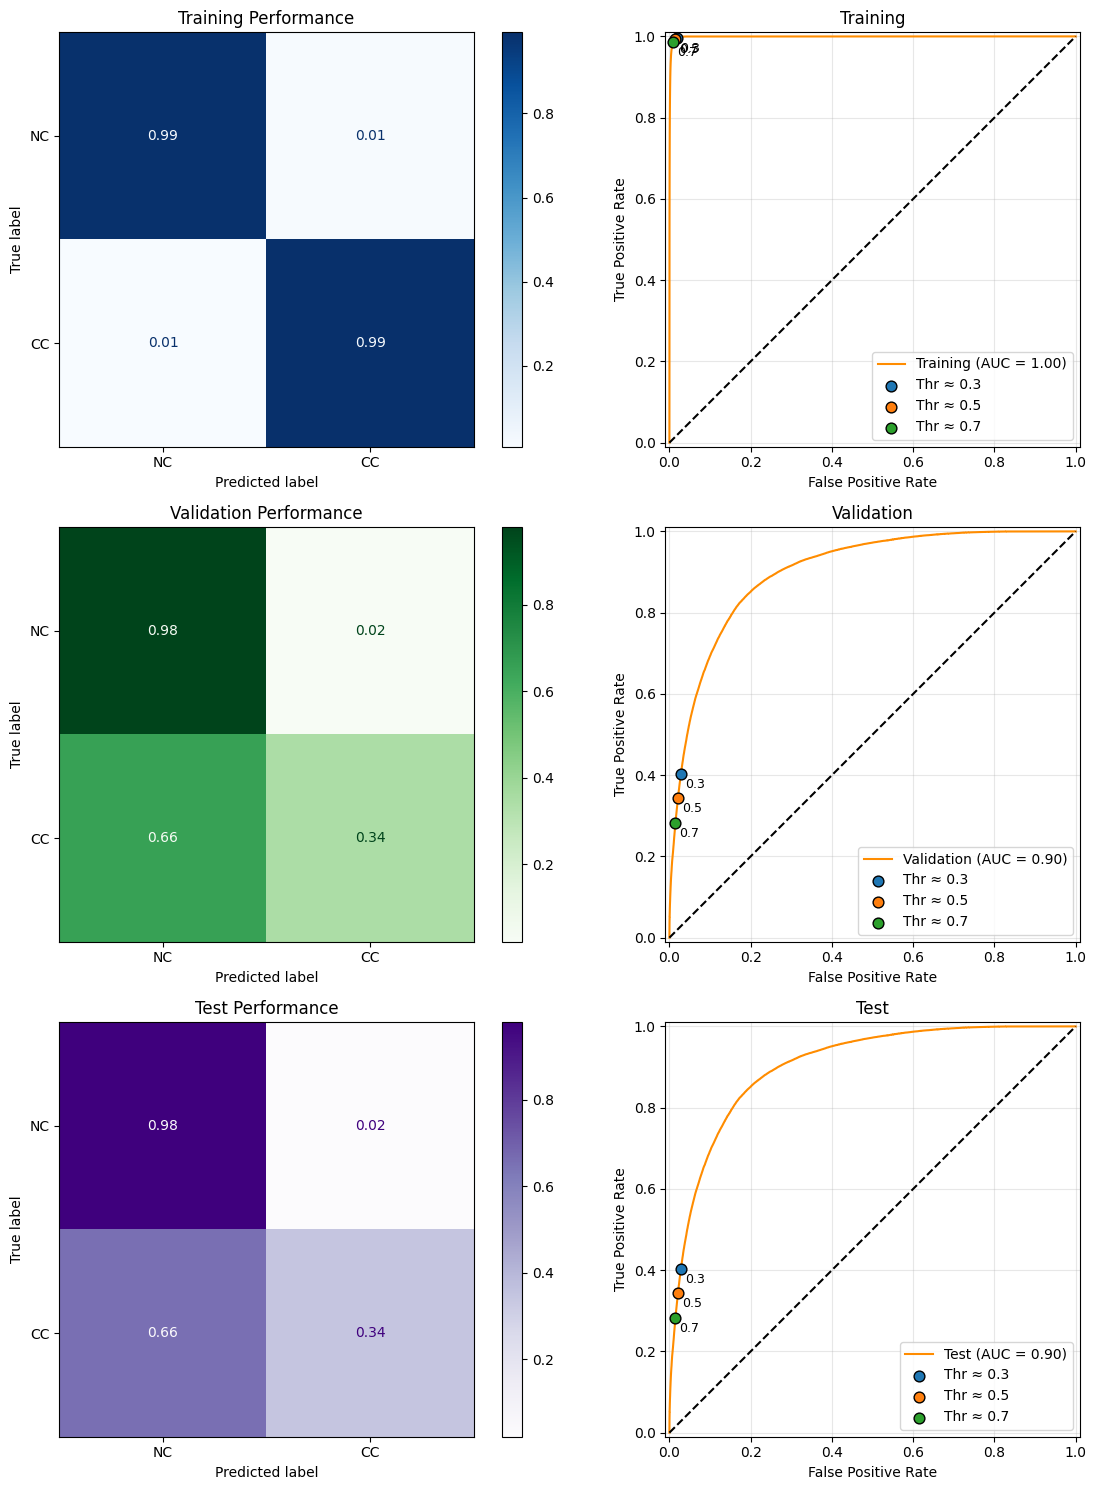

In [47]:
#CM and add metrics #plot auc
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

pf.plotConfusionMatrix(df_balanced_train, title="Training Performance", ax=axes[0,0], cmap='Blues')
pf.plotROC(df_balanced_train, model_name="Training", ax=axes[0,1])
axes[0,1].set_title("Training")

pf.plotConfusionMatrix(df_unbalanced_val, title="Validation Performance", ax=axes[1,0], cmap='Greens')
pf.plotROC(df_unbalanced_val, model_name="Validation", ax=axes[1,1])
axes[1,1].set_title("Validation")

pf.plotConfusionMatrix(df_unbalanced_test, title="Test Performance", ax=axes[2,0], cmap='Purples')
pf.plotROC(df_unbalanced_test, model_name="Test", ax=axes[2,1])
axes[2,1].set_title("Test")

plt.tight_layout()
plt.show()

Training ROC AUC: 0.9991
Validation ROC AUC: 0.9026
Test ROC AUC: 0.9026


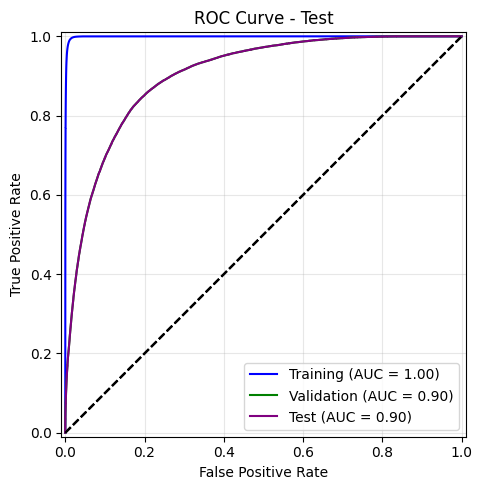

In [48]:
#CM and add metrics #plot auc
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))


pf.plotROC(df_balanced_train, model_name="Training", ax=ax, color='blue', thresholds_to_plot=[])
# axes[0,1].set_title("Training")


pf.plotROC(df_unbalanced_val, model_name="Validation", ax=ax, color='green', thresholds_to_plot=[])
# axes[1,1].set_title("Validation")


pf.plotROC(df_unbalanced_test, model_name="Test", ax=ax, color='purple', thresholds_to_plot=[])
# axes[2,1].set_title("Test")

plt.tight_layout()
plt.show()

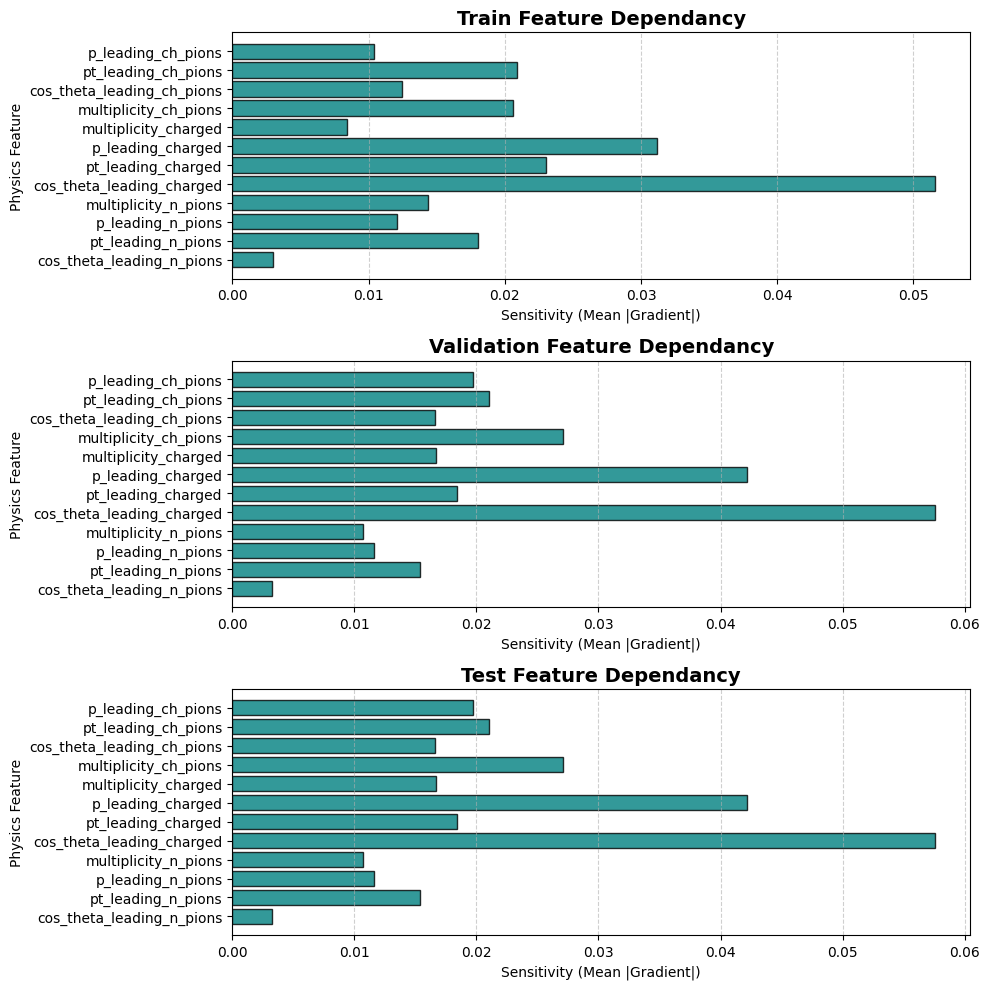

In [49]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

pf.plotFeatureImportance(model_1dCNN, train_data, title='Train Feature Dependancy', ax=axes[0])
pf.plotFeatureImportance(model_1dCNN, val_data, title='Validation Feature Dependancy',ax=axes[1])
pf.plotFeatureImportance(model_1dCNN, test_data, title='Test Feature Dependancy', ax=axes[2])

plt.tight_layout()
plt.show()